# One-Size-Fits-All? Cooperative vs. Non-Cooperative Financial Institutions Under Full Basel-Style Regulation in Brazil

**Research Question:** Under identical prudential regulation, do credit cooperatives
maintain a distinct behavioral profile compared to non-cooperative financial institutions?

**Data:** BACEN IF.data — institution-level quarterly balance sheets, income statements,
and asset composition (2014–2024)

**Method:** Cross-institutional comparison under full methodology, with four specifications
of increasing stringency (raw, size-controlled, CEM-matched, common-support-trimmed)

**Outcomes (8):**
- Capital: Basel ratio, Leverage
- Profitability: ROA, Net interest margin, Cost-to-income (efficiency)
- Credit: Credit ratio, NPL ratio
- Funding: Deposit ratio

---
## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
import statsmodels.formula.api as smf
import warnings

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 150, "font.size": 10, "axes.titlesize": 12,
    "axes.labelsize": 10, "figure.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
})
sns.set_style("whitegrid")

COOP_COLOR = "#2563eb"
NONCOOP_COLOR = "#dc2626"
ACCENT = "#f59e0b"
GREY = "#6b7280"

ROOT = Path(r"C:\Users\arthur.nery\Downloads\credit-paper-ica")
DATA = ROOT / "data"
IF_DATA = DATA / "raw" / "if.data"
PRUD = IF_DATA / "prudential_conglomerates"
PRUD_SUMMARY = PRUD / "summary"
PRUD_SEG = PRUD / "segmentation"
PRUD_ASSETS = PRUD / "assets"
PRUD_INCOME = PRUD / "income_statement"
OUT = DATA / "processed"
OUT.mkdir(parents=True, exist_ok=True)
FIGURES = ROOT / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)
TABLES = ROOT / "tables"
TABLES.mkdir(parents=True, exist_ok=True)

for p, name in [(PRUD_SUMMARY,"Summary"),(PRUD_SEG,"Segmentation"),
                (PRUD_ASSETS,"Assets"),(PRUD_INCOME,"Income")]:
    n = len(list(p.glob("*.csv"))) if p.exists() else 0
    print(f"{name:15s}: {n} files in {p.name}/")

Summary        : 44 files in summary/
Segmentation   : 32 files in segmentation/
Assets         : 44 files in assets/
Income         : 44 files in income_statement/


---
## 1. Data Loading & Panel Construction

In [2]:
def parse_br(s):
    return pd.to_numeric(
        s.astype(str).str.replace(".","",regex=False)
        .str.replace(",",".",regex=False).str.replace("%","",regex=False),
        errors="coerce")

def read_csv(path, **kw):
    for enc in ["utf-8-sig","latin-1","utf-8","cp1252"]:
        try:
            df = pd.read_csv(path, sep=";", encoding=enc, skipinitialspace=True, **kw)
            df.columns = df.columns.str.strip()
            return df
        except (UnicodeDecodeError, ValueError):
            continue
    raise ValueError(f"Could not read {path}")

def load_folder(folder, rename_map, num_cols):
    """Load all CSVs from a folder, rename, parse numerics, add date."""
    chunks = []
    for f in sorted(folder.glob("*.csv")):
        df = read_csv(f)
        rn = {k: v for k, v in rename_map.items() if k in df.columns}
        df = df.rename(columns=rn)
        for c in df.columns:
            if c.upper() in ("TCB","TD","TC"):
                df = df.rename(columns={c: c.lower()})
        chunks.append(df)
    out = pd.concat(chunks, ignore_index=True)
    if "data_str" in out.columns:
        out["date"] = pd.to_datetime(out["data_str"], format="%m/%Y", errors="coerce")
        out = out.dropna(subset=["date"])
    for c in num_cols:
        if c in out.columns:
            out[c] = parse_br(out[c])
    return out

# ── Column maps ────────────────────────────────────────────────────────────
SUMM_MAP = {
    "Instituição":"instituicao","Código":"codigo","SR":"segmento",
    "Cidade":"cidade","UF":"uf","Data":"data_str",
    "Ativo Total":"ativo_total",
    "Carteira de Crédito Classificada":"carteira_credito",
    "Passivo Circulante e Exigível a Longo Prazo e Resultados de Exercícios Futuros":"passivo",
    "Captações":"captacoes","Patrimônio Líquido":"patrimonio_liquido",
    "Lucro Líquido":"lucro_liquido",
    "Patrimônio de Referência para Comparação com o RWA":"pat_referencia",
    "Índice de Basileia":"basileia","Índice de Imobilização":"imobilizacao",
    "Número de Agências":"n_agencias","Número de Postos de Atendimento":"n_postos",
}
SUMM_NUM = ["ativo_total","carteira_credito","passivo","captacoes","patrimonio_liquido",
            "lucro_liquido","pat_referencia","basileia","imobilizacao","n_agencias","n_postos"]

SEG_MAP = {
    "Instituição":"instituicao","Código":"codigo","SR":"segmento","Data":"data_str",
    "Instituição Utiliza Metodologia Simplificada":"simplified",
}

ASSET_MAP = {
    "Código":"codigo","Data":"data_str",
    "Operações de Crédito":"credito_bruto",
    "Operações de Crédito - Provisão sobre Operações de Crédito (d2)":"provisao_credito",
    "Operações de Crédito - Operações de Crédito Líquidas de Provisão (d)":"credito_liquido",
    "TVM e Instrumentos Financeiros Derivativos (c)":"tvm",
    "Disponibilidades (a)":"disponibilidades",
    "Aplicações Interfinanceiras de Liquidez (b)":"aplicacoes_liquidez",
}
ASSET_NUM = ["credito_bruto","provisao_credito","credito_liquido","tvm",
             "disponibilidades","aplicacoes_liquidez"]

INCOME_MAP = {
    "Código":"codigo","Data":"data_str",
    "Resultado de Intermediação Financeira - Receitas de Intermediação Financeira (a) = (a1) + (a2) + (a3) + (a4) + (a5) + (a6)":"receitas_intermediacao",
    "Resultado de Intermediação Financeira - Despesas de Captação (b1)":"despesas_captacao",
    "Resultado de Intermediação Financeira - Resultado de Intermediação Financeira (c) = (a) + (b)":"resultado_intermediacao",
    "Outras Receitas/Despesas Operacionais - Despesas de Pessoal (d3)":"despesas_pessoal",
    "Outras Receitas/Despesas Operacionais - Despesas Administrativas (d4)":"despesas_admin",
}
INCOME_NUM = ["receitas_intermediacao","despesas_captacao","resultado_intermediacao",
              "despesas_pessoal","despesas_admin"]

# ── Load all four sources ──────────────────────────────────────────────────
summary = load_folder(PRUD_SUMMARY, SUMM_MAP, SUMM_NUM)
seg = load_folder(PRUD_SEG, SEG_MAP, [])
assets = load_folder(PRUD_ASSETS, ASSET_MAP, ASSET_NUM)
income = load_folder(PRUD_INCOME, INCOME_MAP, INCOME_NUM)

# ── Coop flag ──────────────────────────────────────────────────────────────
def flag_coop(df):
    if "tcb" in df.columns:
        df["is_coop"] = (df["tcb"].astype(str).str.lower().str.startswith("b3")
            | df["instituicao"].astype(str).str.contains("COOPERAT",case=False,na=False)).astype(int)
    elif "instituicao" in df.columns:
        df["is_coop"] = df["instituicao"].astype(str).str.contains("COOPERAT",case=False,na=False).astype(int)
    return df

summary = flag_coop(summary)
seg = flag_coop(seg)
seg["simplified"] = seg["simplified"].astype(str).str.strip().str.upper()
seg["full_method"] = (seg["simplified"]=="NÃO").astype(int)

print(f"Summary:  {len(summary):,} rows | {summary['codigo'].nunique()} inst")
print(f"Segment:  {len(seg):,} rows | {seg['codigo'].nunique()} inst")
print(f"Assets:   {len(assets):,} rows | {assets['codigo'].nunique()} inst")
print(f"Income:   {len(income):,} rows | {income['codigo'].nunique()} inst")

Summary:  61,380 rows | 1959 inst
Segment:  42,562 rows | 1772 inst
Assets:   61,379 rows | 1959 inst
Income:   61,380 rows | 1959 inst


### 1.1 Merge & Construct Panel

In [3]:
# ── Merge summary + segmentation ───────────────────────────────────────────
panel = summary.merge(
    seg[["codigo","date","simplified","full_method"]].drop_duplicates(subset=["codigo","date"]),
    on=["codigo","date"], how="left")

# ── Merge assets ───────────────────────────────────────────────────────────
asset_cols = ["codigo","date"] + [c for c in ASSET_NUM if c in assets.columns]
panel = panel.merge(assets[asset_cols].drop_duplicates(subset=["codigo","date"]),
                    on=["codigo","date"], how="left")

# ── Merge income ───────────────────────────────────────────────────────────
income_cols = ["codigo","date"] + [c for c in INCOME_NUM if c in income.columns]
panel = panel.merge(income[income_cols].drop_duplicates(subset=["codigo","date"]),
                    on=["codigo","date"], how="left")

# ── Construct outcomes ─────────────────────────────────────────────────────
A = panel["ativo_total"].clip(lower=1)
panel["log_assets"] = np.log(A)

# Capital
panel["basileia_num"] = parse_br(panel["basileia"]) if panel["basileia"].dtype == object else panel["basileia"]
panel["leverage"] = panel["passivo"] / A

# Credit
panel["credit_ratio"] = panel["carteira_credito"] / A
panel["npl_ratio"] = panel["provisao_credito"].abs() / panel["credito_bruto"].abs().replace(0, np.nan)

# Profitability
panel["roa"] = panel["lucro_liquido"] / A
panel["nim"] = panel["resultado_intermediacao"] / A
panel["efficiency"] = (panel["despesas_pessoal"].abs() + panel["despesas_admin"].abs()) / panel["receitas_intermediacao"].abs().replace(0, np.nan)

# Funding
panel["deposit_ratio"] = panel["captacoes"] / A

# ── Metadata ───────────────────────────────────────────────────────────────
panel["year"] = panel["date"].dt.year
panel["year_q"] = panel["date"].dt.to_period("Q")
panel["inst_type"] = np.where(panel["is_coop"]==1, "Coop", "Non-coop")

UF_REGION = {
    'AC':'N','AL':'NE','AM':'N','AP':'N','BA':'NE','CE':'NE','DF':'CO',
    'ES':'SE','GO':'CO','MA':'NE','MG':'SE','MS':'CO','MT':'CO','PA':'N',
    'PB':'NE','PE':'NE','PI':'NE','PR':'S','RJ':'SE','RN':'NE','RO':'N',
    'RR':'N','RS':'S','SC':'S','SE':'NE','SP':'SE','TO':'N'
}
if "uf" in panel.columns:
    panel["region"] = panel["uf"].map(UF_REGION)

# ── Outcomes dictionary ────────────────────────────────────────────────────
OUTCOMES = {
    "basileia_num":  "Basel Capital Ratio (%)",
    "leverage":      "Leverage (Passivo / Assets)",
    "roa":           "Return on Assets",
    "nim":           "Net Interest Margin",
    "efficiency":    "Cost-to-Income Ratio",
    "credit_ratio":  "Credit Portfolio / Assets",
    "npl_ratio":     "NPL Ratio (Provisions / Gross Credit)",
    "deposit_ratio": "Deposit Ratio (Captações / Assets)",
}

# ── Winsorize ──────────────────────────────────────────────────────────────
for col in OUTCOMES:
    if col in panel.columns:
        lo, hi = panel[col].quantile(0.01), panel[col].quantile(0.99)
        panel[col] = panel[col].clip(lower=lo, upper=hi)

print("="*70)
print("PANEL CONSTRUCTED")
print("="*70)
print(f"Full panel: {len(panel):,} obs | {panel['codigo'].nunique()} institutions")
print(f"  Coops:     {panel.loc[panel['is_coop']==1,'codigo'].nunique()}")
print(f"  Non-coops: {panel.loc[panel['is_coop']==0,'codigo'].nunique()}")
print(f"  Date range: {panel['date'].min().strftime('%Y-%m')} to {panel['date'].max().strftime('%Y-%m')}")
print(f"\nOutcome coverage:")
for col, label in OUTCOMES.items():
    n = panel[col].notna().sum()
    print(f"  {label:<40s}: {n:>6,} obs ({100*n/len(panel):.0f}%)")

PANEL CONSTRUCTED
Full panel: 61,380 obs | 1959 institutions
  Coops:     1198
  Non-coops: 762
  Date range: 2014-03 to 2024-12

Outcome coverage:
  Basel Capital Ratio (%)                 : 53,387 obs (87%)
  Leverage (Passivo / Assets)             : 61,071 obs (99%)
  Return on Assets                        : 61,071 obs (99%)
  Net Interest Margin                     : 61,071 obs (99%)
  Cost-to-Income Ratio                    : 60,632 obs (99%)
  Credit Portfolio / Assets               : 61,071 obs (99%)
  NPL Ratio (Provisions / Gross Credit)   : 50,957 obs (83%)
  Deposit Ratio (Captações / Assets)      : 61,071 obs (99%)


---
## 2. The Brazilian Financial System: Cooperatives in Context

### 2.1 Panel Structure Over Time

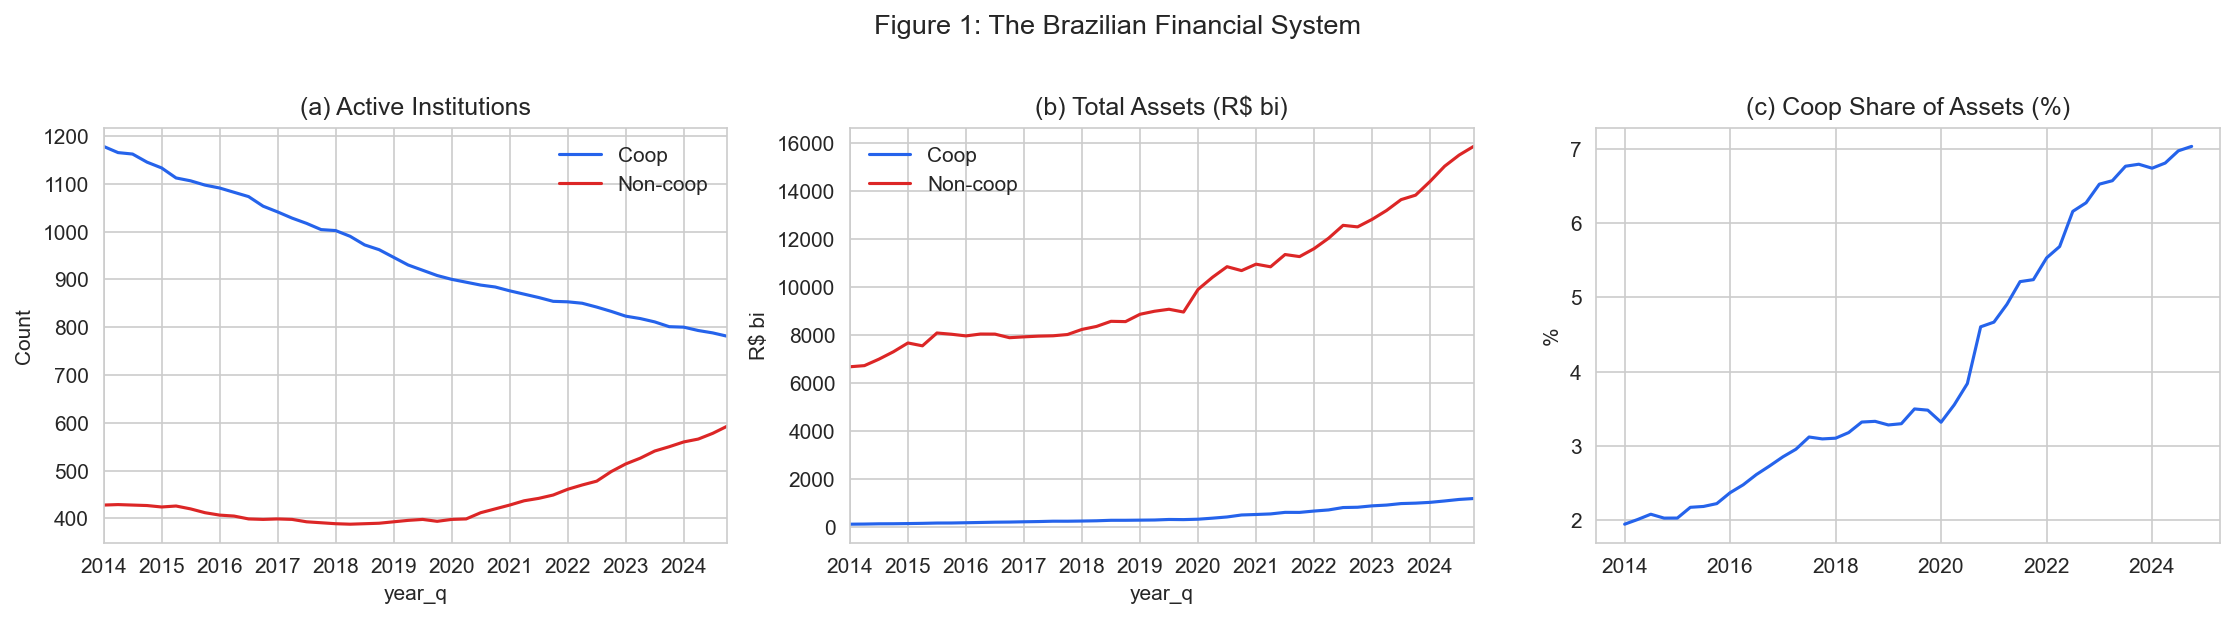


Figure 1 (2024Q4): 781 coops (R$ 1,200 bi, 7.0%) | 593 non-coops (R$ 15,846 bi)


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ts_n = panel.groupby(["year_q","inst_type"])["codigo"].nunique().unstack(fill_value=0)
ts_n.plot(ax=axes[0], color=[COOP_COLOR, NONCOOP_COLOR], linewidth=1.5)
axes[0].set_title("(a) Active Institutions"); axes[0].set_ylabel("Count"); axes[0].legend(frameon=False)

ts_a = panel.groupby(["year_q","inst_type"])["ativo_total"].sum().unstack(fill_value=0) / 1e6
ts_a.plot(ax=axes[1], color=[COOP_COLOR, NONCOOP_COLOR], linewidth=1.5)
axes[1].set_title("(b) Total Assets (R$ bi)"); axes[1].set_ylabel("R$ bi"); axes[1].legend(frameon=False)

ts_share = ts_a.div(ts_a.sum(axis=1), axis=0)
if "Coop" in ts_share.columns:
    axes[2].plot(ts_share.index.to_timestamp(), ts_share["Coop"]*100, color=COOP_COLOR, linewidth=1.5)
    axes[2].set_title("(c) Coop Share of Assets (%)"); axes[2].set_ylabel("%")

fig.suptitle("Figure 1: The Brazilian Financial System", fontsize=13, y=1.02)
fig.tight_layout(); fig.savefig(FIGURES / "fig1_panel_structure.png", bbox_inches="tight"); plt.show()

last_q = panel["year_q"].max()
snap = panel[panel["year_q"]==last_q]
n_c = snap.loc[snap["is_coop"]==1,"codigo"].nunique()
n_n = snap.loc[snap["is_coop"]==0,"codigo"].nunique()
ta_c = snap.loc[snap["is_coop"]==1,"ativo_total"].sum()/1e6
ta_n = snap.loc[snap["is_coop"]==0,"ativo_total"].sum()/1e6
sh = ta_c/(ta_c+ta_n)*100
print(f"\nFigure 1 ({last_q}): {n_c} coops (R$ {ta_c:,.0f} bi, {sh:.1f}%) | {n_n} non-coops (R$ {ta_n:,.0f} bi)")

### 2.2 Size Distribution

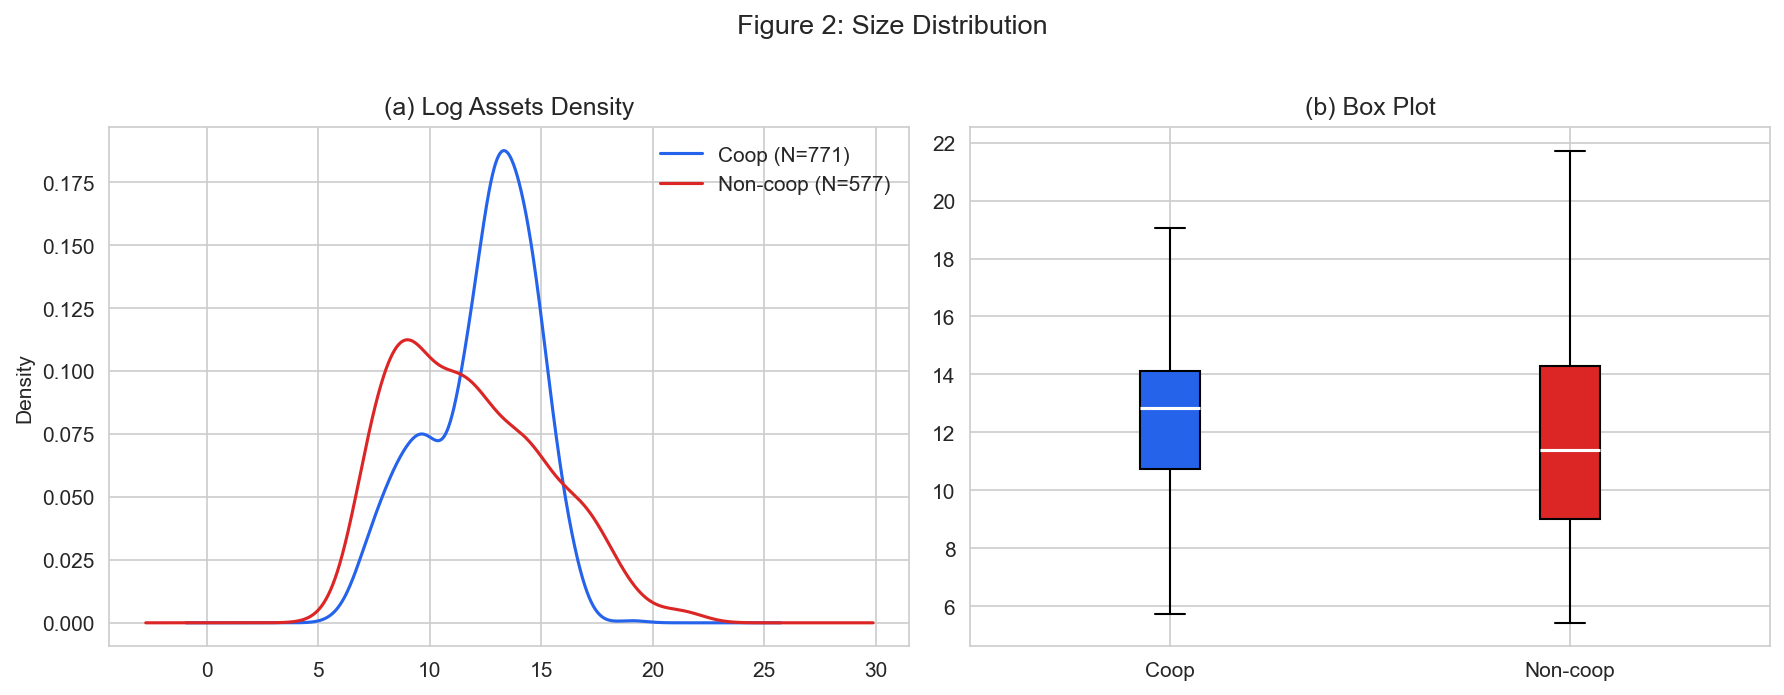

Coop: log_assets mean=12.35 med=12.84 | assets mean=1,556,097 med=378,274
Non-coop: log_assets mean=11.80 med=11.40 | assets mean=27,463,479 med=89,386


In [5]:
snap = panel[panel["year_q"]==panel["year_q"].max()]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for val, label, color in [(1,"Coop",COOP_COLOR),(0,"Non-coop",NONCOOP_COLOR)]:
    sub = snap.loc[snap["is_coop"]==val, "log_assets"].dropna()
    sub.plot.kde(ax=axes[0], label=f"{label} (N={len(sub)})", color=color, linewidth=1.5)
axes[0].set_title("(a) Log Assets Density"); axes[0].legend(frameon=False)
data_box = [snap.loc[snap["is_coop"]==1,"log_assets"].dropna(), snap.loc[snap["is_coop"]==0,"log_assets"].dropna()]
bp = axes[1].boxplot(data_box, labels=["Coop","Non-coop"], patch_artist=True, medianprops=dict(color="white",linewidth=1.5))
bp["boxes"][0].set_facecolor(COOP_COLOR); bp["boxes"][1].set_facecolor(NONCOOP_COLOR)
axes[1].set_title("(b) Box Plot")
fig.suptitle("Figure 2: Size Distribution", fontsize=13, y=1.02)
fig.tight_layout(); fig.savefig(FIGURES / "fig2_size.png", bbox_inches="tight"); plt.show()

for val, label in [(1,"Coop"),(0,"Non-coop")]:
    la = snap.loc[snap["is_coop"]==val, "log_assets"]
    at = snap.loc[snap["is_coop"]==val, "ativo_total"]
    print(f"{label}: log_assets mean={la.mean():.2f} med={la.median():.2f} | assets mean={at.mean():,.0f} med={at.median():,.0f}")

### 2.3 Outcome Distributions

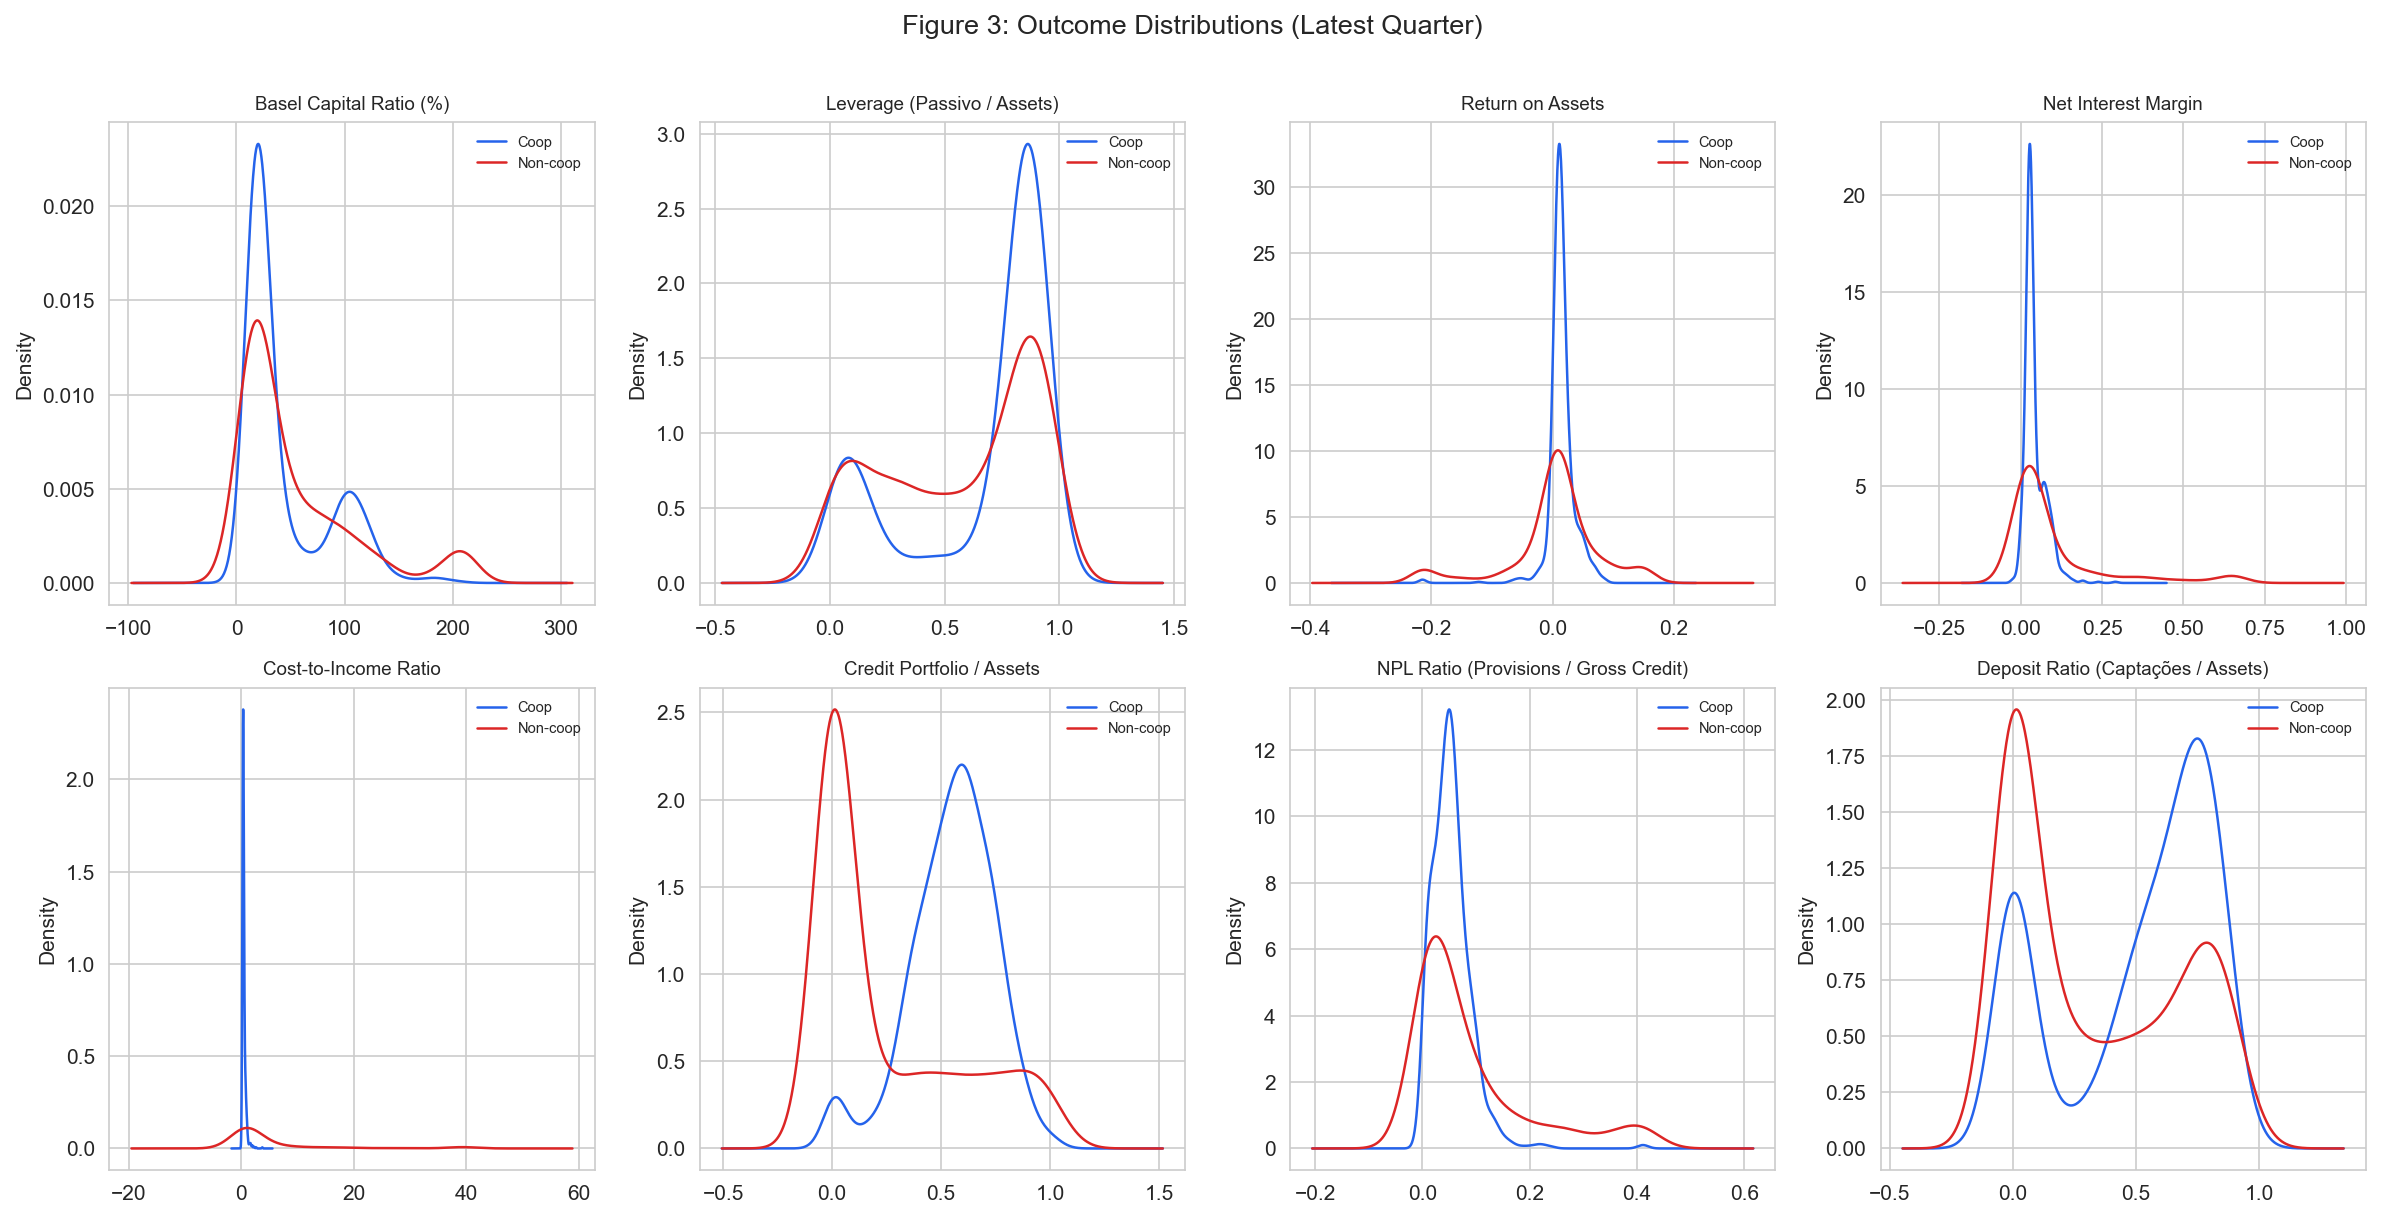


Figure 3 — Unconditional means (latest quarter):
Outcome                                          Coop   Non-coop       Diff
────────────────────────────────────────────────────────────────────────────
Basel Capital Ratio (%)                      +43.8532   +53.4434    -9.5902
Leverage (Passivo / Assets)                   +0.6659    +0.5684    +0.0975
Return on Assets                              +0.0144    +0.0041    +0.0104
Net Interest Margin                           +0.0432    +0.0968    -0.0535
Cost-to-Income Ratio                          +0.4325    +4.9047    -4.4722
Credit Portfolio / Assets                     +0.5518    +0.2454    +0.3064
NPL Ratio (Provisions / Gross Credit)         +0.0539    +0.0890    -0.0352
Deposit Ratio (Captações / Assets)            +0.5030    +0.3188    +0.1842


In [6]:
snap = panel[panel["year_q"]==panel["year_q"].max()]
n_out = len(OUTCOMES)
ncols = 4; nrows = (n_out + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4*nrows))
axes = axes.flatten()
for i, (col, label) in enumerate(OUTCOMES.items()):
    ax = axes[i]
    for val, gl, color in [(1,"Coop",COOP_COLOR),(0,"Non-coop",NONCOOP_COLOR)]:
        sub = snap.loc[snap["is_coop"]==val, col].dropna()
        if len(sub) > 10:
            sub.plot.kde(ax=ax, label=gl, color=color, linewidth=1.2)
    ax.set_title(label, fontsize=9); ax.legend(fontsize=7, frameon=False)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
fig.suptitle("Figure 3: Outcome Distributions (Latest Quarter)", fontsize=13, y=1.01)
fig.tight_layout(); fig.savefig(FIGURES / "fig3_distributions.png", bbox_inches="tight"); plt.show()

print("\nFigure 3 — Unconditional means (latest quarter):")
print(f"{'Outcome':<42s} {'Coop':>10s} {'Non-coop':>10s} {'Diff':>10s}")
print("─"*76)
for col, label in OUTCOMES.items():
    cm = snap.loc[snap["is_coop"]==1, col].mean()
    nm = snap.loc[snap["is_coop"]==0, col].mean()
    print(f"{label:<42s} {cm:>+10.4f} {nm:>+10.4f} {cm-nm:>+10.4f}")

### 2.4 Time Series

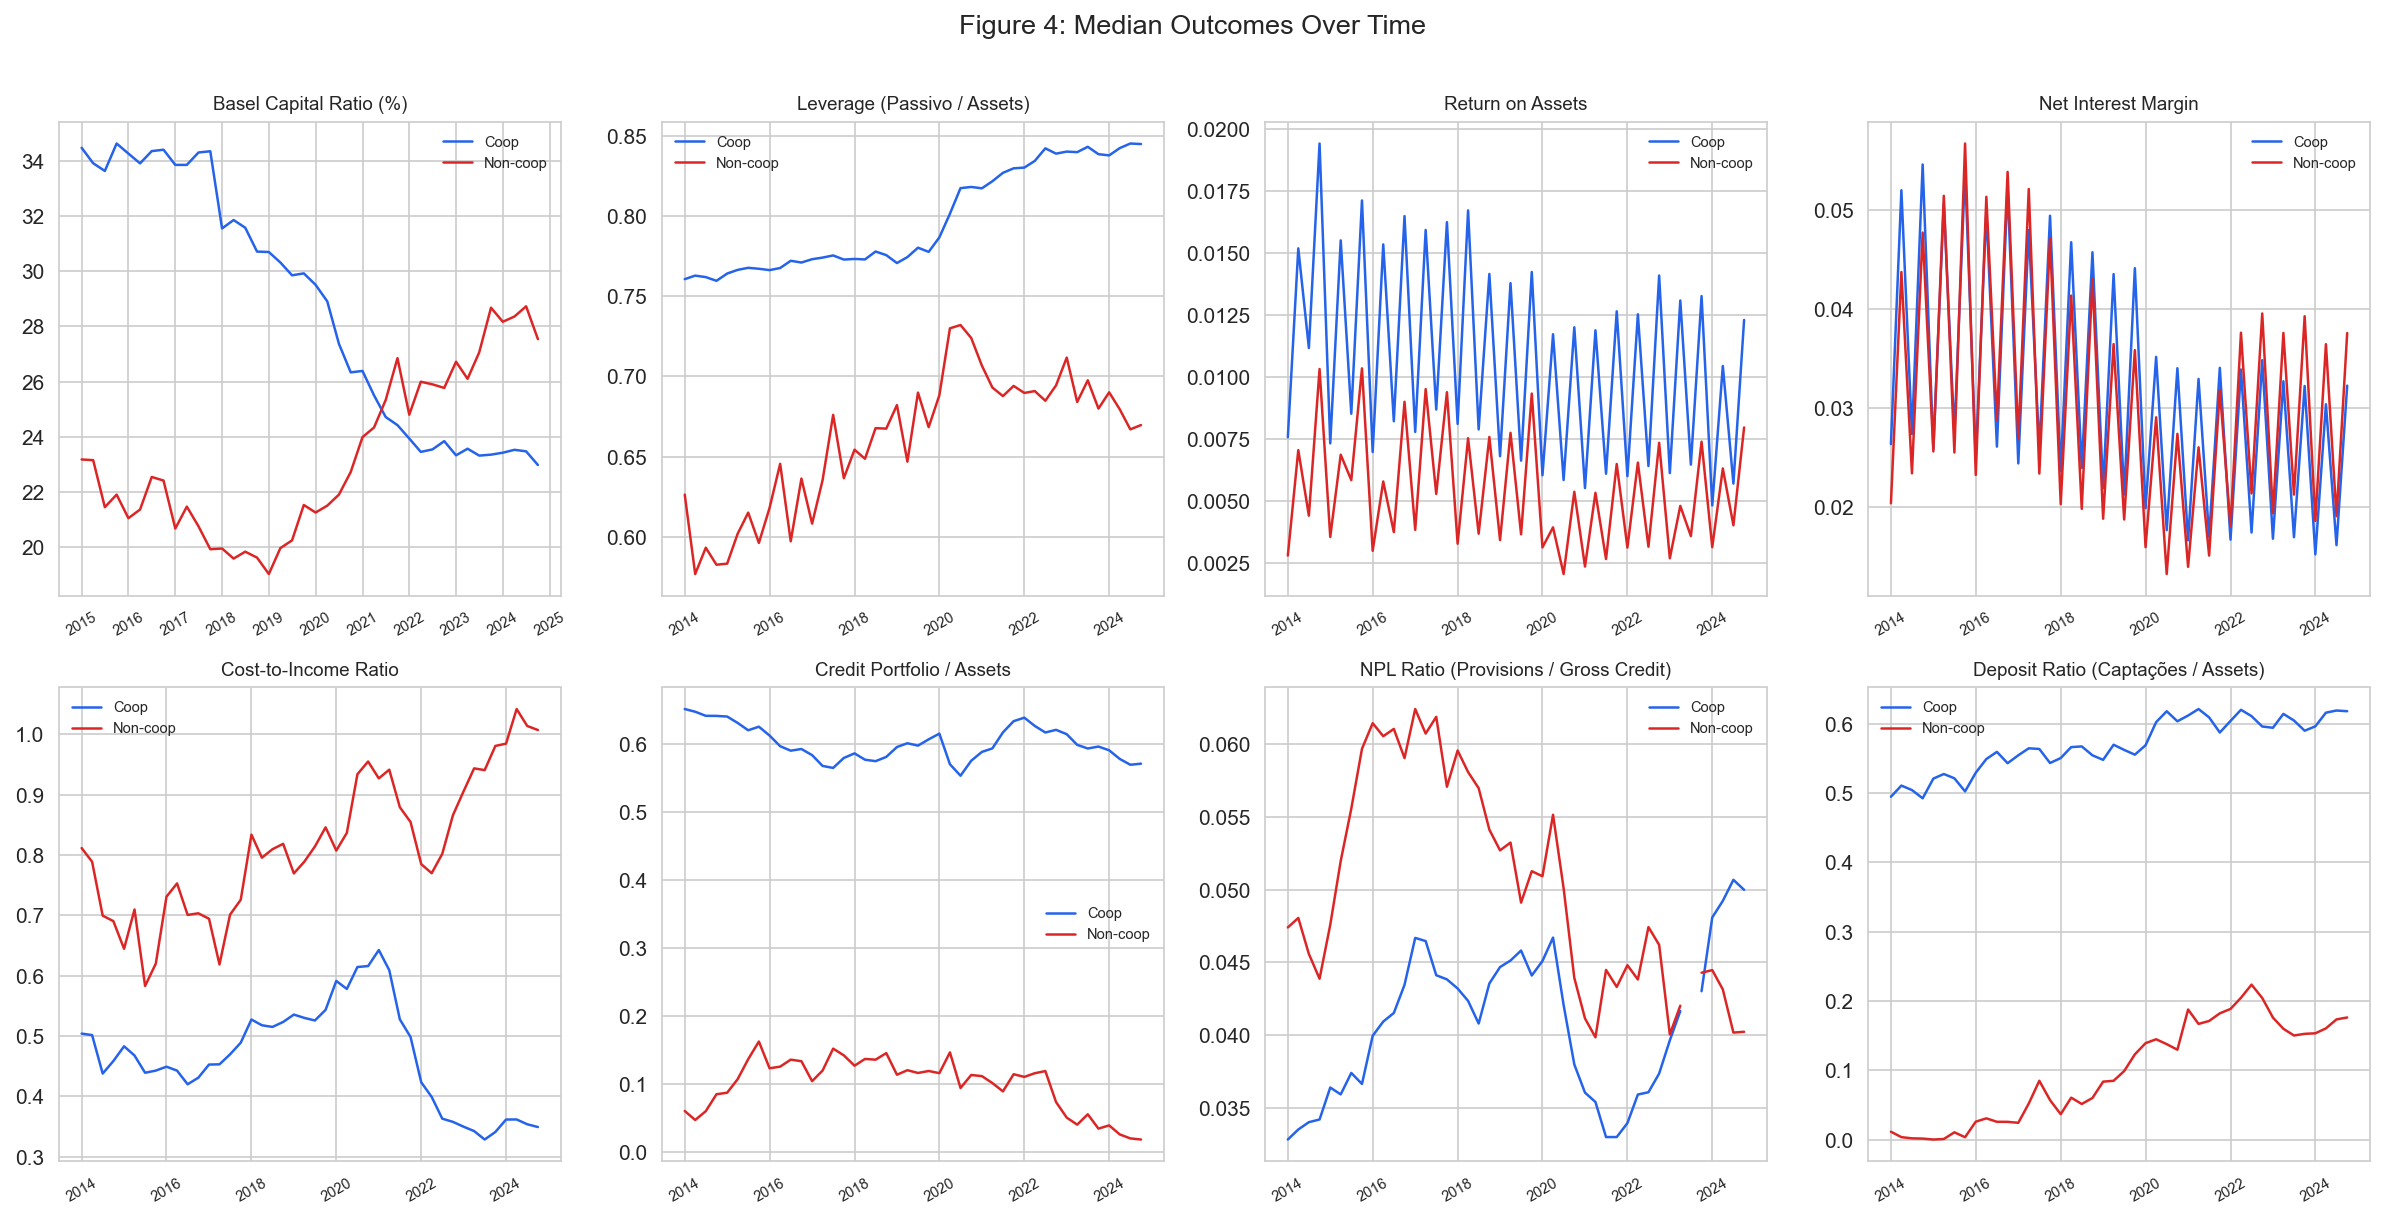


Figure 4 — Median, 2014Q1 → 2024Q4:
  Basel Capital Ratio (%)             Coop : +nan → +22.9750 (Δ=+nan)
  Basel Capital Ratio (%)             NC   : +nan → +27.5400 (Δ=+nan)
  Leverage (Passivo / Assets)         Coop : +0.7605 → +0.8447 (Δ=+0.0842)
  Leverage (Passivo / Assets)         NC   : +0.6263 → +0.6696 (Δ=+0.0433)
  Return on Assets                    Coop : +0.0076 → +0.0123 (Δ=+0.0047)
  Return on Assets                    NC   : +0.0028 → +0.0080 (Δ=+0.0052)
  Net Interest Margin                 Coop : +0.0263 → +0.0323 (Δ=+0.0059)
  Net Interest Margin                 NC   : +0.0204 → +0.0376 (Δ=+0.0172)
  Cost-to-Income Ratio                Coop : +0.5041 → +0.3493 (Δ=-0.1548)
  Cost-to-Income Ratio                NC   : +0.8115 → +1.0071 (Δ=+0.1955)
  Credit Portfolio / Assets           Coop : +0.6507 → +0.5705 (Δ=-0.0802)
  Credit Portfolio / Assets           NC   : +0.0609 → +0.0190 (Δ=-0.0419)
  NPL Ratio (Provisions / Gross Credit) Coop : +0.0328 → +0.0500 (Δ=+0.01

In [7]:
ncols = 4; nrows = (len(OUTCOMES) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4*nrows))
axes = axes.flatten()
for i, (col, label) in enumerate(OUTCOMES.items()):
    ax = axes[i]
    for val, gl, color in [(1,"Coop",COOP_COLOR),(0,"Non-coop",NONCOOP_COLOR)]:
        ts = panel.loc[panel["is_coop"]==val].groupby("year_q")[col].median()
        ax.plot(ts.index.to_timestamp(), ts.values, color=color, label=gl, linewidth=1.2)
    ax.set_title(label, fontsize=9); ax.legend(fontsize=7, frameon=False)
    ax.tick_params(axis="x", rotation=30, labelsize=7)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
fig.suptitle("Figure 4: Median Outcomes Over Time", fontsize=13, y=1.01)
fig.tight_layout(); fig.savefig(FIGURES / "fig4_timeseries.png", bbox_inches="tight"); plt.show()

first_q, last_q = panel["year_q"].min(), panel["year_q"].max()
print(f"\nFigure 4 — Median, {first_q} → {last_q}:")
for col, label in OUTCOMES.items():
    for val, gl in [(1,"Coop"),(0,"NC")]:
        v1 = panel[(panel["is_coop"]==val)&(panel["year_q"]==first_q)][col].median()
        v2 = panel[(panel["is_coop"]==val)&(panel["year_q"]==last_q)][col].median()
        print(f"  {label:<35s} {gl:<5s}: {v1:+.4f} → {v2:+.4f} (Δ={v2-v1:+.4f})")

### 2.5 Regulatory Environment

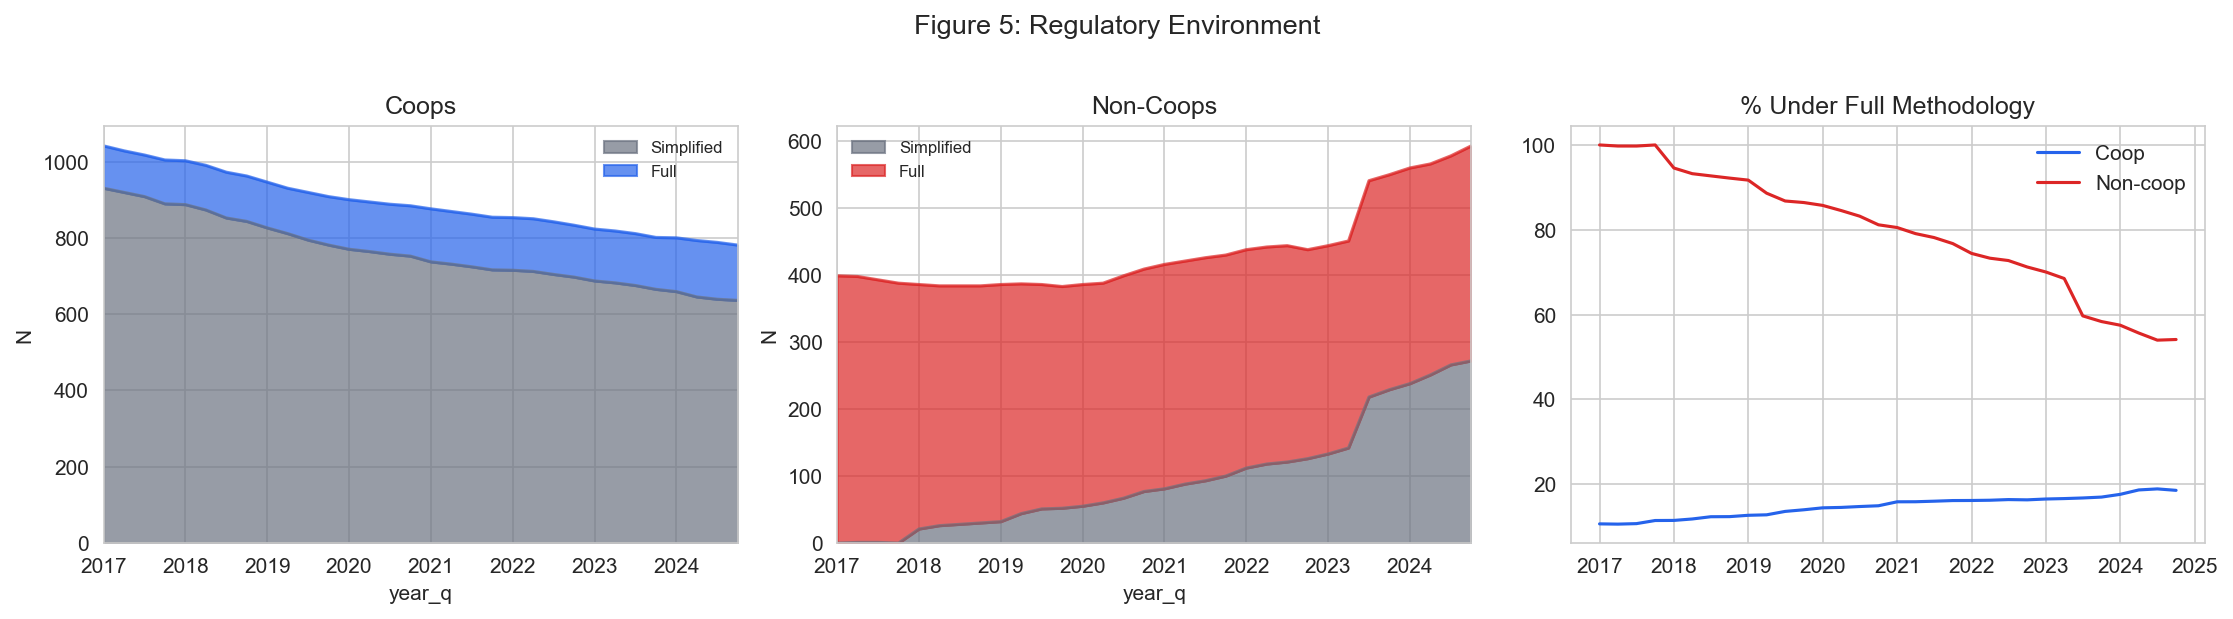

Coop: 145 full (19%), 636 simplified
Non-coop: 321 full (54%), 272 simplified


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, val, title, col in [(axes[0],1,"Coops",COOP_COLOR),(axes[1],0,"Non-Coops",NONCOOP_COLOR)]:
    m = panel[panel["is_coop"]==val].groupby(["year_q","full_method"])["codigo"].nunique().unstack(fill_value=0)
    m.columns = ["Simplified","Full"]
    m.plot.area(ax=ax, color=[GREY, col], alpha=0.7)
    ax.set_title(title); ax.set_ylabel("N"); ax.legend(frameon=False, fontsize=8)
meth_c = panel[panel["is_coop"]==1].groupby(["year_q","full_method"])["codigo"].nunique().unstack(fill_value=0)
meth_n = panel[panel["is_coop"]==0].groupby(["year_q","full_method"])["codigo"].nunique().unstack(fill_value=0)
meth_c.columns = meth_n.columns = ["Simplified","Full"]
sh_c = meth_c["Full"]/meth_c.sum(axis=1)*100
sh_n = meth_n["Full"]/meth_n.sum(axis=1)*100
axes[2].plot(sh_c.index.to_timestamp(), sh_c.values, color=COOP_COLOR, label="Coop", linewidth=1.5)
axes[2].plot(sh_n.index.to_timestamp(), sh_n.values, color=NONCOOP_COLOR, label="Non-coop", linewidth=1.5)
axes[2].set_title("% Under Full Methodology"); axes[2].legend(frameon=False)
fig.suptitle("Figure 5: Regulatory Environment", fontsize=13, y=1.02)
fig.tight_layout(); fig.savefig(FIGURES / "fig5_regulatory.png", bbox_inches="tight"); plt.show()

latest = panel[panel["year_q"]==panel["year_q"].max()]
for val, label in [(1,"Coop"),(0,"Non-coop")]:
    s = latest[latest["is_coop"]==val]
    nf = s[s["full_method"]==1]["codigo"].nunique()
    ns = s[s["full_method"]==0]["codigo"].nunique()
    print(f"{label}: {nf} full ({100*nf/(nf+ns+1e-9):.0f}%), {ns} simplified")

### 2.6 Geography

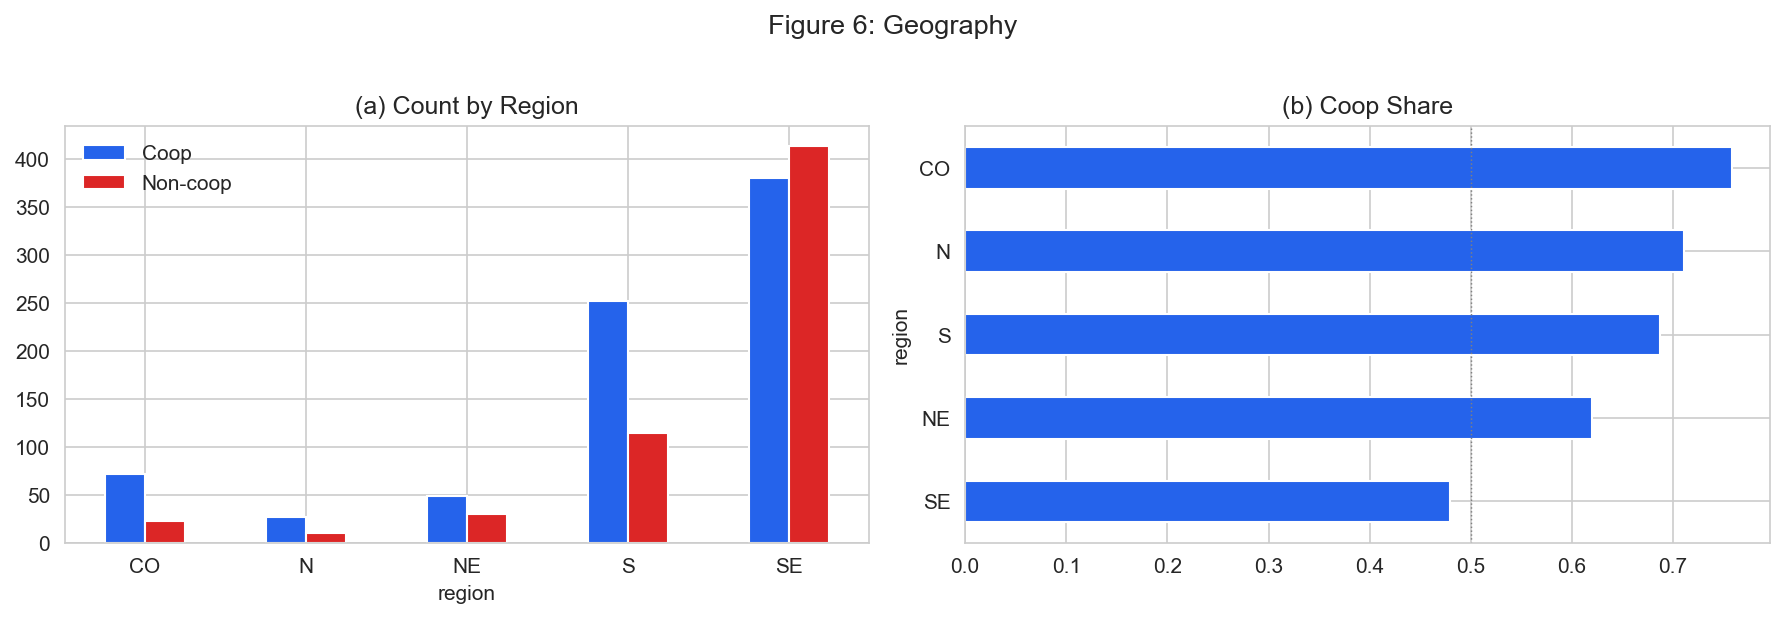

  CO: 72 coops, 23 non-coops (76% coop)
  N: 27 coops, 11 non-coops (71% coop)
  NE: 49 coops, 30 non-coops (62% coop)
  S: 252 coops, 115 non-coops (69% coop)
  SE: 381 coops, 414 non-coops (48% coop)


In [9]:
if "region" in panel.columns:
    snap = panel[panel["year_q"]==panel["year_q"].max()].drop_duplicates("codigo")
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    ct = pd.crosstab(snap["region"], snap["inst_type"])
    ct[["Coop","Non-coop"]].plot.bar(ax=axes[0], color=[COOP_COLOR, NONCOOP_COLOR], edgecolor="white")
    axes[0].set_title("(a) Count by Region"); axes[0].tick_params(axis="x", rotation=0); axes[0].legend(frameon=False)
    ct_pct = ct.div(ct.sum(axis=1), axis=0)
    if "Coop" in ct_pct.columns:
        ct_pct["Coop"].sort_values().plot.barh(ax=axes[1], color=COOP_COLOR)
        axes[1].set_title("(b) Coop Share"); axes[1].axvline(0.5, color="grey", linestyle=":", linewidth=0.7)
    fig.suptitle("Figure 6: Geography", fontsize=13, y=1.02)
    fig.tight_layout(); fig.savefig(FIGURES / "fig6_geography.png", bbox_inches="tight"); plt.show()
    for region in sorted(snap["region"].dropna().unique()):
        nc = snap[(snap["region"]==region)&(snap["is_coop"]==1)]["codigo"].nunique()
        nn = snap[(snap["region"]==region)&(snap["is_coop"]==0)]["codigo"].nunique()
        print(f"  {region}: {nc} coops, {nn} non-coops ({100*nc/(nc+nn+1e-9):.0f}% coop)")

### 2.7 Descriptive Statistics Table

In [10]:
desc_rows = []
for val, label in [(1,"Coop"),(0,"Non-coop")]:
    sub = panel[panel["is_coop"]==val]
    row = {"Type":label, "N_inst":sub["codigo"].nunique(), "N_obs":len(sub)}
    for col, cl in list(OUTCOMES.items())+[("log_assets","Log Assets")]:
        if col in sub.columns:
            row[f"{cl} mean"] = sub[col].mean()
            row[f"{cl} sd"] = sub[col].std()
            row[f"{cl} p50"] = sub[col].median()
    desc_rows.append(row)
tableA1 = pd.DataFrame(desc_rows).round(4)
tableA1.to_csv(TABLES / "tableA1_descriptive.csv", index=False)
print("Table A1: Descriptive Statistics"); display(tableA1.T)

Table A1: Descriptive Statistics


,0,1
Type,Coop,Non-coop
N_inst,1198,762
N_obs,41936,19444
Basel Capital Ratio (%) mean,51.2651,42.2845
Basel Capital Ratio (%) sd,44.1741,44.7925
Basel Capital Ratio (%) p50,29.04,23.015
Leverage (Passivo / Assets) mean,0.6267,0.5646
Leverage (Passivo / Assets) sd,0.3175,0.3208
Leverage (Passivo / Assets) p50,0.7926,0.6638
Return on Assets mean,0.0106,0.0026


### 2.8 Correlation Structure

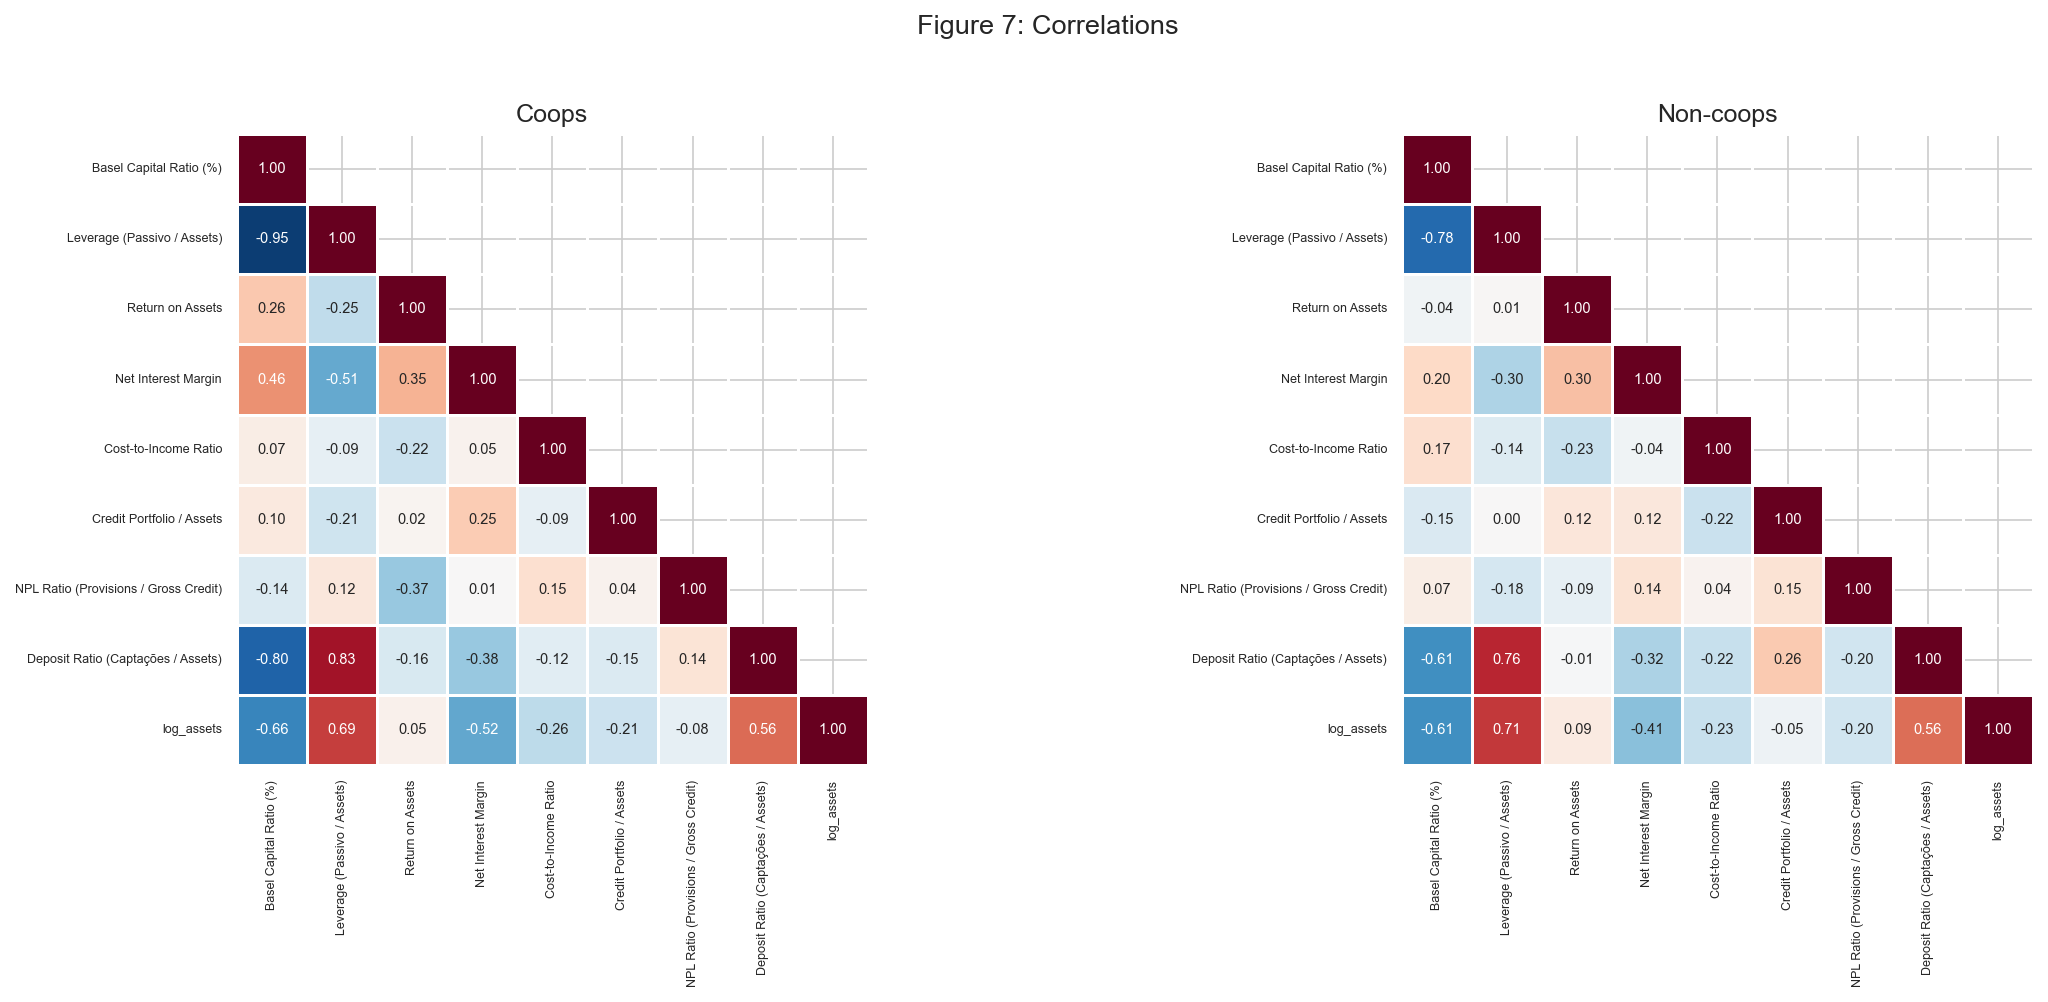


Notable correlations (coops, |r| > 0.4):
  Basel Capital Ratio (%) × Leverage (Passivo / Assets): r=-0.950
  Basel Capital Ratio (%) × Net Interest Margin: r=+0.458
  Basel Capital Ratio (%) × Deposit Ratio (Captações / Assets): r=-0.799
  Basel Capital Ratio (%) × log_assets: r=-0.659
  Leverage (Passivo / Assets) × Net Interest Margin: r=-0.515
  Leverage (Passivo / Assets) × Deposit Ratio (Captações / Assets): r=+0.833
  Leverage (Passivo / Assets) × log_assets: r=+0.688
  Net Interest Margin × log_assets: r=-0.518
  Deposit Ratio (Captações / Assets) × log_assets: r=+0.560


In [11]:
corr_cols = [c for c in OUTCOMES if c in panel.columns] + ["log_assets"]
corr_labels = [OUTCOMES.get(c,c) for c in corr_cols]
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
for ax, val, title in [(axes[0],1,"Coops"),(axes[1],0,"Non-coops")]:
    sub = panel[panel["is_coop"]==val][corr_cols].dropna()
    corr = sub.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
                ax=ax, square=True, linewidths=0.5, xticklabels=corr_labels,
                yticklabels=corr_labels, cbar=False, annot_kws={"size":7})
    ax.set_title(title); ax.tick_params(labelsize=6)
fig.suptitle("Figure 7: Correlations", fontsize=13, y=1.02)
fig.tight_layout(); fig.savefig(FIGURES / "fig7_correlations.png", bbox_inches="tight"); plt.show()

print("\nNotable correlations (coops, |r| > 0.4):")
cc = panel[panel["is_coop"]==1][corr_cols].dropna().corr()
for i in range(len(corr_cols)):
    for j in range(i+1, len(corr_cols)):
        r = cc.iloc[i,j]
        if abs(r) > 0.4:
            print(f"  {corr_labels[i]} × {corr_labels[j]}: r={r:+.3f}")

---
## 3. Analysis Sample: Full Methodology Institutions

In [12]:
l2 = panel[panel["full_method"]==1].copy()
l2["size_bin"] = pd.qcut(l2["log_assets"], q=5, labels=False, duplicates="drop")

print("="*70)
print("ANALYSIS SAMPLE: FULL METHODOLOGY")
print("="*70)
n_c = l2.loc[l2["is_coop"]==1,"codigo"].nunique()
n_n = l2.loc[l2["is_coop"]==0,"codigo"].nunique()
print(f"  {l2['codigo'].nunique()} institutions | {len(l2):,} obs")
print(f"  Coops: {n_c} ({100*n_c/(n_c+n_n):.1f}%) | Non-coops: {n_n}")
print(f"  {l2['date'].min().strftime('%Y-%m')} to {l2['date'].max().strftime('%Y-%m')}")
print(f"\nOutcome coverage in analysis sample:")
for col, label in OUTCOMES.items():
    nc = l2[col].notna().sum()
    print(f"  {label:<42s}: {nc:>6,} obs ({100*nc/len(l2):.0f}%)")
print(f"\nMeans (analysis sample):")
print(f"{'Outcome':<42s} {'Coop':>10s} {'Non-coop':>10s}")
print("─"*65)
for col, label in OUTCOMES.items():
    cm = l2.loc[l2["is_coop"]==1, col].mean()
    nm = l2.loc[l2["is_coop"]==0, col].mean()
    print(f"{label:<42s} {cm:>+10.4f} {nm:>+10.4f}")

ANALYSIS SAMPLE: FULL METHODOLOGY
  650 institutions | 15,004 obs
  Coops: 168 (25.8%) | Non-coops: 483
  2017-03 to 2024-12

Outcome coverage in analysis sample:
  Basel Capital Ratio (%)                   : 14,445 obs (96%)
  Leverage (Passivo / Assets)               : 14,920 obs (99%)
  Return on Assets                          : 14,920 obs (99%)
  Net Interest Margin                       : 14,920 obs (99%)
  Cost-to-Income Ratio                      : 14,769 obs (98%)
  Credit Portfolio / Assets                 : 14,920 obs (99%)
  NPL Ratio (Provisions / Gross Credit)     :  9,955 obs (66%)
  Deposit Ratio (Captações / Assets)        : 14,920 obs (99%)

Means (analysis sample):
Outcome                                          Coop   Non-coop
─────────────────────────────────────────────────────────────────
Basel Capital Ratio (%)                      +23.5798   +34.6104
Leverage (Passivo / Assets)                   +0.8590    +0.6110
Return on Assets                              

### 3.1 Common Support

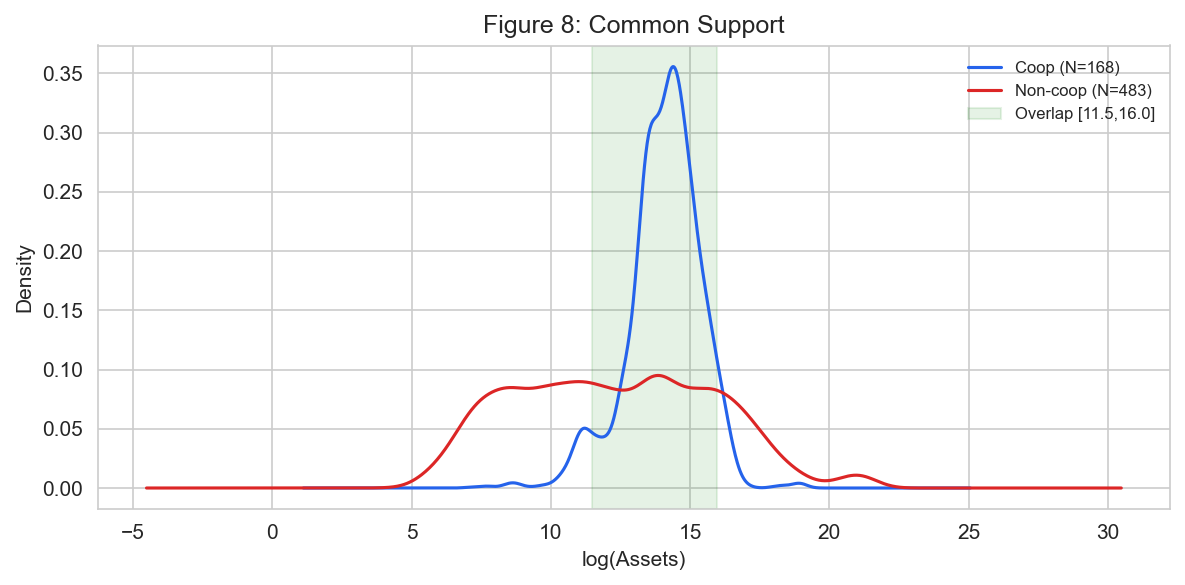


Overlap [11.47, 15.96]:
  Coops:     155 inst / 3,738 obs (90%)
  Non-coops: 233 inst / 4,232 obs (39%)


In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
for val, label, color in [(1,"Coop",COOP_COLOR),(0,"Non-coop",NONCOOP_COLOR)]:
    sub = l2.loc[l2["is_coop"]==val, "log_assets"].dropna()
    sub.plot.kde(ax=ax, label=f"{label} (N={l2.loc[l2['is_coop']==val,'codigo'].nunique()})", color=color, linewidth=1.5)
c95 = l2.loc[l2["is_coop"]==1,"log_assets"].quantile([0.05,0.95])
n95 = l2.loc[l2["is_coop"]==0,"log_assets"].quantile([0.05,0.95])
OV_LO = max(c95.iloc[0], n95.iloc[0])
OV_HI = min(c95.iloc[1], n95.iloc[1])
ax.axvspan(OV_LO, OV_HI, alpha=0.1, color="green", label=f"Overlap [{OV_LO:.1f},{OV_HI:.1f}]")
ax.set_title("Figure 8: Common Support"); ax.set_xlabel("log(Assets)"); ax.legend(frameon=False, fontsize=8)
fig.tight_layout(); fig.savefig(FIGURES / "fig8_overlap.png", bbox_inches="tight"); plt.show()

c_in = l2[(l2["is_coop"]==1)&(l2["log_assets"].between(OV_LO,OV_HI))]
n_in = l2[(l2["is_coop"]==0)&(l2["log_assets"].between(OV_LO,OV_HI))]
print(f"\nOverlap [{OV_LO:.2f}, {OV_HI:.2f}]:")
print(f"  Coops:     {c_in['codigo'].nunique()} inst / {len(c_in):,} obs ({100*len(c_in)/len(l2[l2['is_coop']==1]):.0f}%)")
print(f"  Non-coops: {n_in['codigo'].nunique()} inst / {len(n_in):,} obs ({100*len(n_in)/len(l2[l2['is_coop']==0]):.0f}%)")

### 3.2 Matching & Balance

CEM on: ['size_bin', 'region']

Full:    650 inst | 15,004 obs
CEM:     599 inst | 13,734 obs (dropped 51)
Trimmed: 388 inst | 7,970 obs


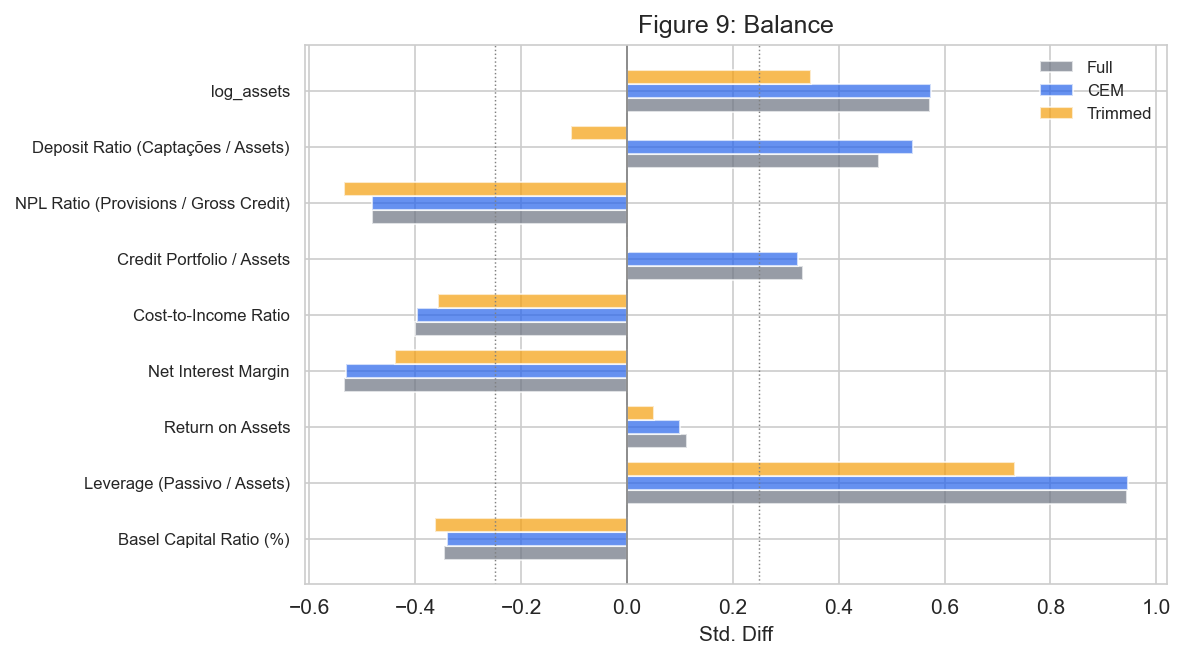


Balance (|d|<0.25 = ✓):
  Basel Capital Ratio (%)                    Full:-0.346⚠ CEM:-0.341⚠ Trim:-0.363⚠
  Leverage (Passivo / Assets)                Full:+0.945⚠ CEM:+0.947⚠ Trim:+0.732⚠
  Return on Assets                           Full:+0.114✓ CEM:+0.101✓ Trim:+0.051✓
  Net Interest Margin                        Full:-0.534⚠ CEM:-0.532⚠ Trim:-0.438⚠
  Cost-to-Income Ratio                       Full:-0.400⚠ CEM:-0.397⚠ Trim:-0.358⚠
  Credit Portfolio / Assets                  Full:+0.332⚠ CEM:+0.323⚠ Trim:+0.002✓
  NPL Ratio (Provisions / Gross Credit)      Full:-0.481⚠ CEM:-0.481⚠ Trim:-0.535⚠
  Deposit Ratio (Captações / Assets)         Full:+0.476⚠ CEM:+0.541⚠ Trim:-0.105✓
  log_assets                                 Full:+0.573⚠ CEM:+0.574⚠ Trim:+0.347⚠


In [14]:
snap_m = l2.drop_duplicates("codigo")[["codigo","is_coop","size_bin","region","log_assets"]].dropna()
match_vars = ["size_bin","region"] if snap_m["region"].nunique() > 1 else ["size_bin"]
print(f"CEM on: {match_vars}")

strata = snap_m.groupby(match_vars)["is_coop"].agg(["sum","count"])
strata["n_coop"] = strata["sum"]; strata["n_nc"] = strata["count"]-strata["sum"]
valid = strata[(strata["n_coop"]>0)&(strata["n_nc"]>0)].index
if len(match_vars)==1:
    mids = snap_m[snap_m[match_vars[0]].isin(valid)]["codigo"].tolist()
else:
    snap_m["_s"] = list(zip(*[snap_m[v] for v in match_vars]))
    mids = snap_m[snap_m["_s"].isin(valid)]["codigo"].tolist()

l2_cem = l2[l2["codigo"].isin(mids)].copy()
l2_trim = l2[l2["log_assets"].between(OV_LO, OV_HI)].copy()

print(f"\nFull:    {l2['codigo'].nunique()} inst | {len(l2):,} obs")
print(f"CEM:     {l2_cem['codigo'].nunique()} inst | {len(l2_cem):,} obs (dropped {l2['codigo'].nunique()-l2_cem['codigo'].nunique()})")
print(f"Trimmed: {l2_trim['codigo'].nunique()} inst | {len(l2_trim):,} obs")

# Balance
def balance(df, covs):
    rows = []
    for col, label in covs:
        if col not in df.columns: continue
        c = df.loc[df["is_coop"]==1, col].dropna(); n = df.loc[df["is_coop"]==0, col].dropna()
        if len(c)<5 or len(n)<5: continue
        psd = np.sqrt((c.var()*len(c)+n.var()*len(n))/(len(c)+len(n)))
        rows.append({"Variable":label, "Std.Diff":(c.mean()-n.mean())/psd if psd>0 else np.nan})
    return pd.DataFrame(rows)

covs = [(c, OUTCOMES.get(c,c)) for c in list(OUTCOMES)+["log_assets"]]
bf = balance(l2, covs).rename(columns={"Std.Diff":"Full"})
bc = balance(l2_cem, covs).rename(columns={"Std.Diff":"CEM"})
bt = balance(l2_trim, covs).rename(columns={"Std.Diff":"Trimmed"})
bal = bf.merge(bc, on="Variable").merge(bt, on="Variable")
bal.to_csv(TABLES / "table1_balance.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 4.5))
y = np.arange(len(bal)); w = 0.25
ax.barh(y-w, bal["Full"], height=w, color=GREY, label="Full", alpha=0.7)
ax.barh(y, bal["CEM"], height=w, color=COOP_COLOR, label="CEM", alpha=0.7)
ax.barh(y+w, bal["Trimmed"], height=w, color=ACCENT, label="Trimmed", alpha=0.7)
ax.axvline(0, color="grey", linewidth=0.8)
ax.axvline(-0.25, color="grey", linestyle=":", linewidth=0.7)
ax.axvline(0.25, color="grey", linestyle=":", linewidth=0.7)
ax.set_yticks(y); ax.set_yticklabels(bal["Variable"], fontsize=8)
ax.set_xlabel("Std. Diff"); ax.set_title("Figure 9: Balance"); ax.legend(fontsize=8, frameon=False)
fig.tight_layout(); fig.savefig(FIGURES / "fig9_balance.png", bbox_inches="tight"); plt.show()

print("\nBalance (|d|<0.25 = ✓):")
for _, r in bal.iterrows():
    sf = "✓" if abs(r["Full"])<0.25 else "⚠"
    sc = "✓" if abs(r["CEM"])<0.25 else "⚠"
    st = "✓" if abs(r["Trimmed"])<0.25 else "⚠"
    print(f"  {r['Variable']:<42s} Full:{r['Full']:+.3f}{sf} CEM:{r['CEM']:+.3f}{sc} Trim:{r['Trimmed']:+.3f}{st}")

---
## 4. Main Results: The Cooperative Differential

In [15]:
specs = [
    ("(1) Raw",       l2,      "{out} ~ is_coop"),
    ("(2) Full+ctrl", l2,      "{out} ~ is_coop + log_assets + C(t)"),
    ("(3) CEM+ctrl",  l2_cem,  "{out} ~ is_coop + log_assets + C(t)"),
    ("(4) Trim+ctrl", l2_trim, "{out} ~ is_coop + log_assets + C(t)"),
]

all_results = {}
for sl, df, ftmpl in specs:
    sr = {}
    for out, ol in OUTCOMES.items():
        if out not in df.columns: continue
        sub = df[["is_coop","log_assets","date",out]].dropna().copy()
        if len(sub) < 50: continue
        sub["t"] = sub["date"].dt.to_period("Q").apply(lambda x: x.ordinal)
        try:
            res = smf.ols(ftmpl.format(out=out), data=sub).fit(cov_type="HC3")
            c = res.params["is_coop"]; ci = res.conf_int().loc["is_coop"]; p = res.pvalues["is_coop"]
            sig = "***" if p<0.01 else "**" if p<0.05 else "*" if p<0.1 else ""
            sr[out] = {"label":ol,"coef":c,"ci_lo":ci.iloc[0],"ci_hi":ci.iloc[1],"pval":p,"sig":sig,"N":len(sub)}
        except Exception as e:
            print(f"  {sl}/{out}: {e}")
    all_results[sl] = sr

# ── Full printout ──────────────────────────────────────────────────────────
print("="*105)
print("TABLE 2: COOP DIFFERENTIAL — FOUR SPECIFICATIONS")
print("="*105)
for out, ol in OUTCOMES.items():
    print(f"\n  {ol}")
    print(f"  {'Spec':<15s} {'β':>10s} {'95% CI':>26s} {'p':>8s} {'N':>7s}")
    print(f"  {'─'*15} {'─'*10} {'─'*26} {'─'*8} {'─'*7}")
    for sl, sr in all_results.items():
        if out in sr:
            v = sr[out]
            print(f"  {sl:<15s} {v['coef']:>+10.5f} [{v['ci_lo']:>+11.5f}, {v['ci_hi']:>+11.5f}] {v['pval']:>7.4f}{v['sig']:<3s} {v['N']:>6d}")

print(f"\n{'='*105}")
print("STABILITY ASSESSMENT")
print(f"{'='*105}")
for out, ol in OUTCOMES.items():
    coefs = [all_results[s][out]["coef"] for s in all_results if out in all_results[s]]
    signs = [np.sign(c) for c in coefs]
    same = len(set(signs))==1
    allsig = all(all_results[s][out]["pval"]<0.05 for s in all_results if out in all_results[s])
    if same and allsig:
        v = "STABLE ✓✓✓"
    elif same:
        v = "STABLE (direction) ✓"
    else:
        v = "SIGN FLIP ⚠"
    print(f"  {ol:<42s} [{min(coefs):+.4f}, {max(coefs):+.4f}]  {v}")

# Save
rows = []
for sl, sr in all_results.items():
    for out, v in sr.items():
        rows.append({"Spec":sl, "Outcome":v["label"], "coef":v["coef"],
                     "ci_lo":v["ci_lo"], "ci_hi":v["ci_hi"], "pval":v["pval"], "N":v["N"]})
table2 = pd.DataFrame(rows).round(5)
table2.to_csv(TABLES / "table2_four_specs.csv", index=False)

TABLE 2: COOP DIFFERENTIAL — FOUR SPECIFICATIONS

  Basel Capital Ratio (%)
  Spec                     β                     95% CI        p       N
  ─────────────── ────────── ────────────────────────── ──────── ───────
  (1) Raw          -11.04779 [  -11.86667,   -10.22890]  0.0000***  14433
  (2) Full+ctrl     -6.88957 [   -7.58647,    -6.19268]  0.0000***  14433
  (3) CEM+ctrl      -7.15943 [   -7.89405,    -6.42481]  0.0000***  13249
  (4) Trim+ctrl     -8.07460 [   -9.09126,    -7.05795]  0.0000***   7933

  Leverage (Passivo / Assets)
  Spec                     β                     95% CI        p       N
  ─────────────── ────────── ────────────────────────── ──────── ───────
  (1) Raw           +0.24795 [   +0.24172,    +0.25418]  0.0000***  14920
  (2) Full+ctrl     +0.14713 [   +0.14217,    +0.15209]  0.0000***  14920
  (3) CEM+ctrl      +0.14894 [   +0.14369,    +0.15419]  0.0000***  13686
  (4) Trim+ctrl     +0.10991 [   +0.10309,    +0.11674]  0.0000***   7970

  Return

### Figure 10: Coefficient Stability

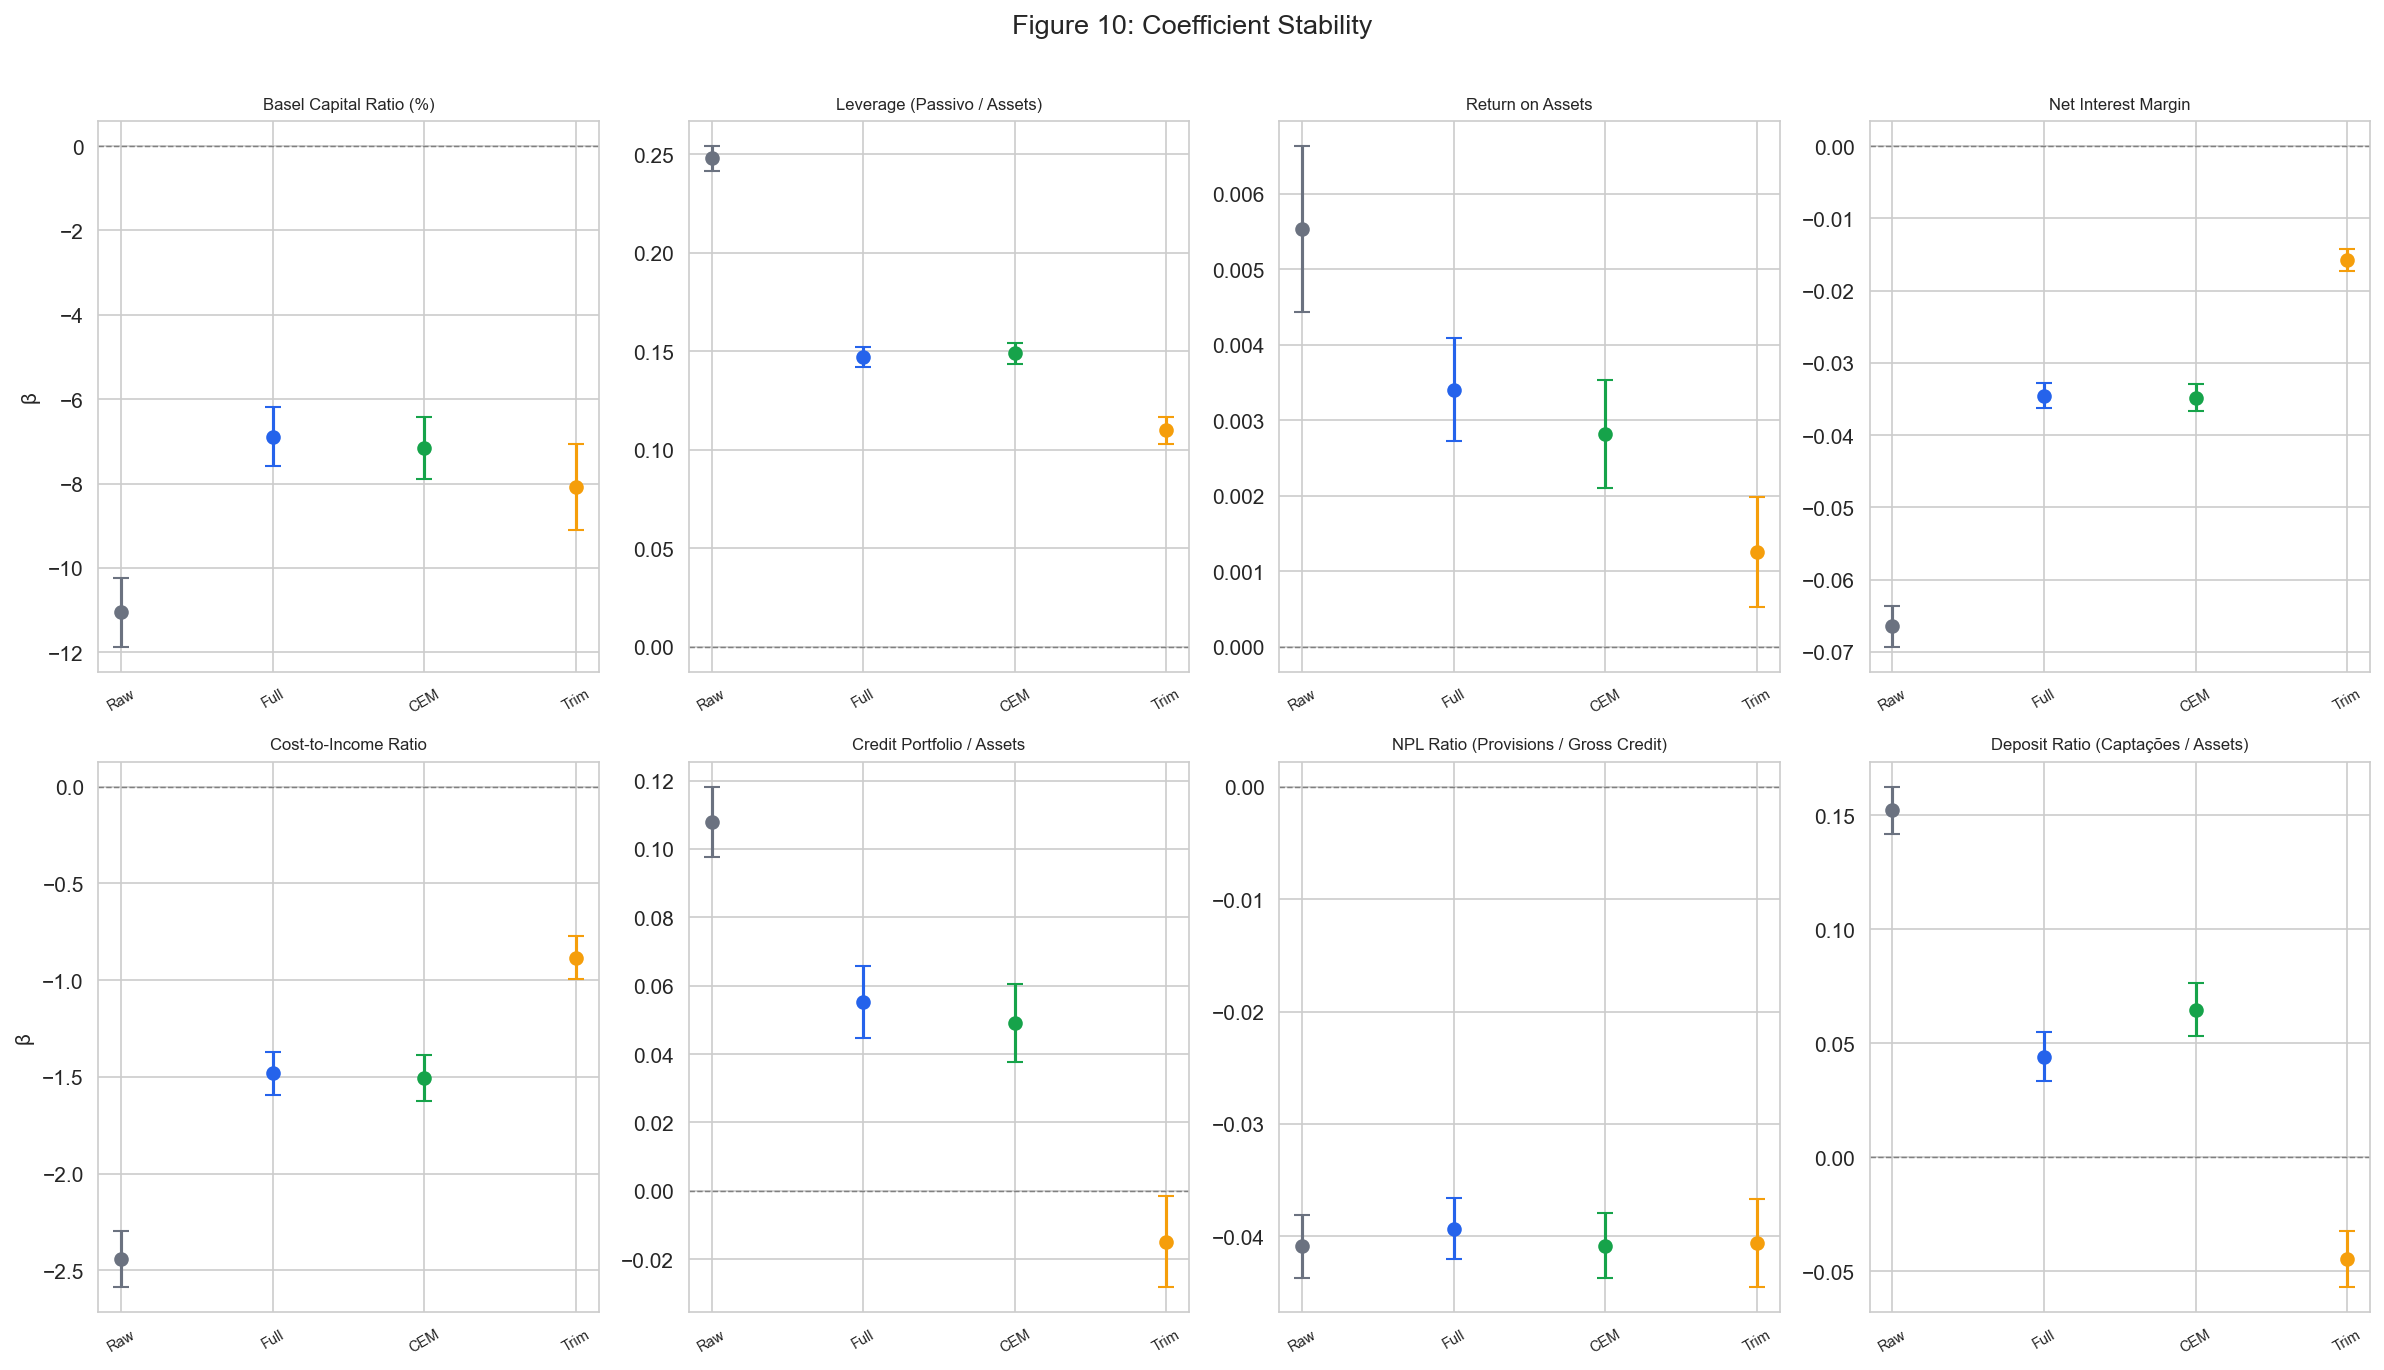


Figure 10 — β across specs:
  Basel Capital Ratio (%)                    (1) Raw:-11.0478, (2) Full+ctrl:-6.8896, (3) CEM+ctrl:-7.1594, (4) Trim+ctrl:-8.0746
  Leverage (Passivo / Assets)                (1) Raw:+0.2479, (2) Full+ctrl:+0.1471, (3) CEM+ctrl:+0.1489, (4) Trim+ctrl:+0.1099
  Return on Assets                           (1) Raw:+0.0055, (2) Full+ctrl:+0.0034, (3) CEM+ctrl:+0.0028, (4) Trim+ctrl:+0.0013
  Net Interest Margin                        (1) Raw:-0.0665, (2) Full+ctrl:-0.0345, (3) CEM+ctrl:-0.0348, (4) Trim+ctrl:-0.0158
  Cost-to-Income Ratio                       (1) Raw:-2.4406, (2) Full+ctrl:-1.4822, (3) CEM+ctrl:-1.5064, (4) Trim+ctrl:-0.8841
  Credit Portfolio / Assets                  (1) Raw:+0.1079, (2) Full+ctrl:+0.0554, (3) CEM+ctrl:+0.0490, (4) Trim+ctrl:-0.0149
  NPL Ratio (Provisions / Gross Credit)      (1) Raw:-0.0409, (2) Full+ctrl:-0.0393, (3) CEM+ctrl:-0.0408, (4) Trim+ctrl:-0.0406
  Deposit Ratio (Captações / Assets)         (1) Raw:+0.1520, (2) F

In [16]:
outcomes_plot = [k for k in OUTCOMES if all(k in sr for sr in all_results.values())]
n = len(outcomes_plot)
ncols = 4; nrows = (n+ncols-1)//ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 4.5*nrows), squeeze=False)
axes_flat = axes.flatten()
spec_colors = [GREY, COOP_COLOR, "#16a34a", ACCENT]
spec_short = ["Raw","Full","CEM","Trim"]

for j, out in enumerate(outcomes_plot):
    ax = axes_flat[j]
    for i, (sl, sr) in enumerate(all_results.items()):
        if out not in sr: continue
        v = sr[out]
        ax.errorbar(i, v["coef"], yerr=[[abs(v["coef"]-v["ci_lo"])],[abs(v["ci_hi"]-v["coef"])]],
                    fmt="o", color=spec_colors[i], capsize=4, markersize=6)
    ax.axhline(0, color="grey", linestyle="--", linewidth=0.7)
    ax.set_xticks(range(len(spec_short))); ax.set_xticklabels(spec_short, fontsize=7, rotation=30)
    ax.set_title(OUTCOMES[out], fontsize=8)
    if j%ncols==0: ax.set_ylabel("β")
for k in range(j+1, len(axes_flat)):
    axes_flat[k].set_visible(False)
fig.suptitle("Figure 10: Coefficient Stability", fontsize=13, y=1.01)
fig.tight_layout(); fig.savefig(FIGURES / "fig10_stability.png", bbox_inches="tight"); plt.show()

print("\nFigure 10 — β across specs:")
for out in outcomes_plot:
    cs = [(s, all_results[s][out]["coef"]) for s in all_results if out in all_results[s]]
    print(f"  {OUTCOMES[out]:<42s} {', '.join(f'{s}:{c:+.4f}' for s,c in cs)}")

---
## 5. Deep Dive: Stable Findings

Stable outcomes: 6
  Basel Capital Ratio (%)
  Leverage (Passivo / Assets)
  Return on Assets
  Net Interest Margin
  Cost-to-Income Ratio
  NPL Ratio (Provisions / Gross Credit)


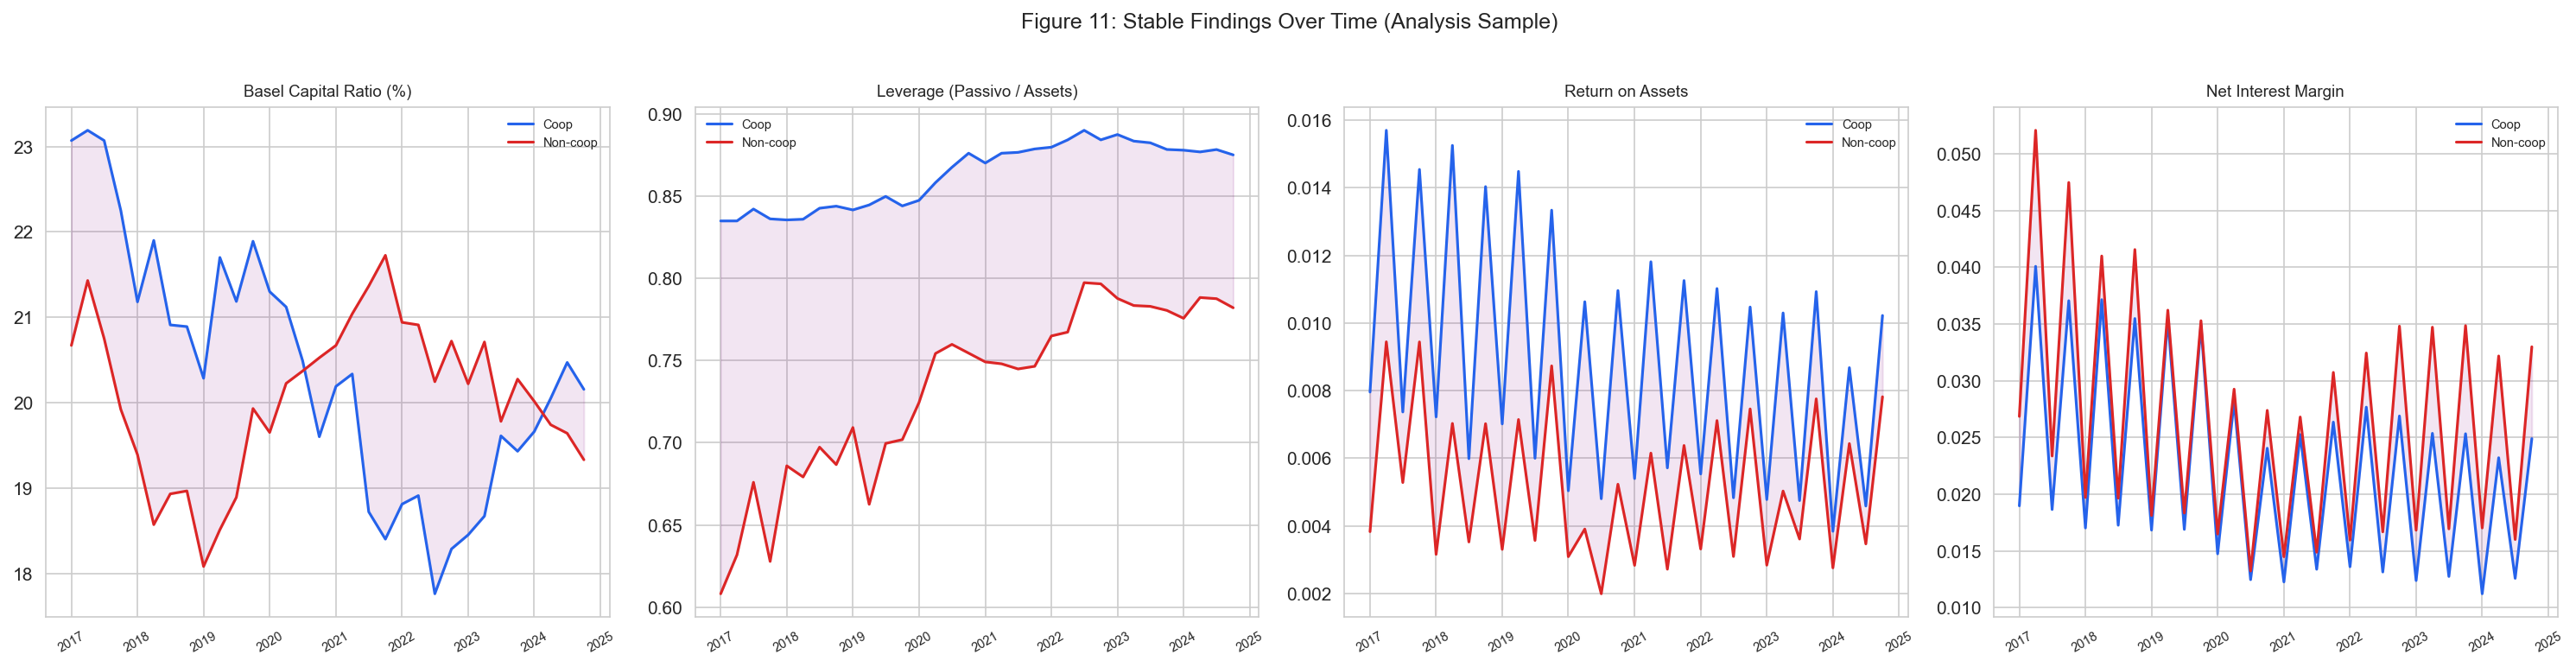


Persistent gaps (analysis sample, CEM spec):
  Basel Capital Ratio (%)                    Median gap: +0.0350 | CEM β: -7.1594
  Leverage (Passivo / Assets)                Median gap: +0.1333 | CEM β: +0.1489
  Return on Assets                           Median gap: +0.0025 | CEM β: +0.0028
  Net Interest Margin                        Median gap: -0.0091 | CEM β: -0.0348
  Cost-to-Income Ratio                       Median gap: -0.3624 | CEM β: -1.5064
  NPL Ratio (Provisions / Gross Credit)      Median gap: -0.0029 | CEM β: -0.0408


In [17]:
stable = [k for k in OUTCOMES if all(
    np.sign(all_results[s].get(k,{}).get("coef",0)) == np.sign(all_results[list(all_results.keys())[0]].get(k,{}).get("coef",0))
    for s in all_results if k in all_results[s])]

print(f"Stable outcomes: {len(stable)}")
for s in stable:
    print(f"  {OUTCOMES[s]}")

fig, axes = plt.subplots(1, min(len(stable),4), figsize=(5*min(len(stable),4), 5), squeeze=False)
axes = axes[0]
for idx, out in enumerate(stable[:4]):
    ax = axes[idx]; label = OUTCOMES[out]
    for val, gl, color in [(1,"Coop",COOP_COLOR),(0,"Non-coop",NONCOOP_COLOR)]:
        ts = l2.loc[l2["is_coop"]==val].groupby("year_q")[out].median()
        ax.plot(ts.index.to_timestamp(), ts.values, color=color, label=gl, linewidth=1.5)
    ts_c = l2.loc[l2["is_coop"]==1].groupby("year_q")[out].median()
    ts_n = l2.loc[l2["is_coop"]==0].groupby("year_q")[out].median()
    ci = ts_c.index.intersection(ts_n.index)
    ax.fill_between(ci.to_timestamp(), ts_c[ci].values, ts_n[ci].values, alpha=0.1, color="purple")
    ax.set_title(label, fontsize=9); ax.legend(fontsize=7, frameon=False)
    ax.tick_params(axis="x", rotation=30, labelsize=7)
fig.suptitle("Figure 11: Stable Findings Over Time (Analysis Sample)", fontsize=12, y=1.02)
fig.tight_layout(); fig.savefig(FIGURES / "fig11_stable.png", bbox_inches="tight"); plt.show()

print("\nPersistent gaps (analysis sample, CEM spec):")
for out in stable:
    cem = all_results.get("(3) CEM+ctrl",{}).get(out,{})
    gap = l2.loc[l2["is_coop"]==1,out].median() - l2.loc[l2["is_coop"]==0,out].median()
    print(f"  {OUTCOMES[out]:<42s} Median gap: {gap:+.4f} | CEM β: {cem.get('coef',np.nan):+.4f}")

---
## 6. Unstable Findings

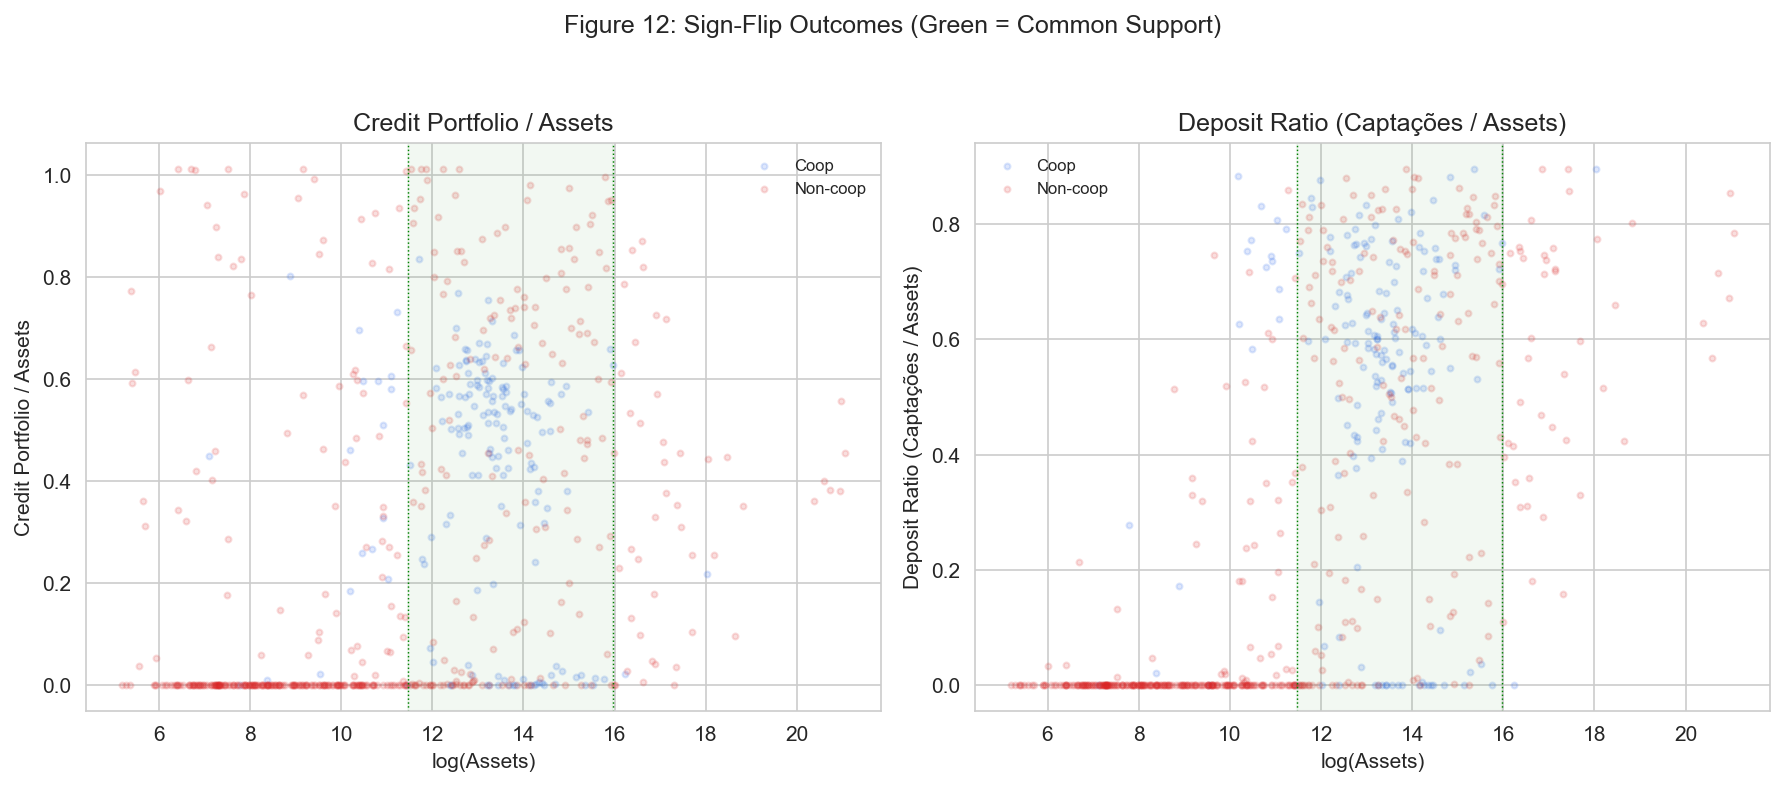


Sign flip decomposition:

  Credit Portfolio / Assets:
    Inside overlap:  Coop=0.4369, NC=0.4363, gap=+0.0006
    Outside overlap: Coop=0.2897, NC=0.2352, gap=+0.0544

  Deposit Ratio (Captações / Assets):
    Inside overlap:  Coop=0.4841, NC=0.5139, gap=-0.0297
    Outside overlap: Coop=0.5068, NC=0.2181, gap=+0.2888


In [18]:
unstable = [k for k in OUTCOMES if k not in stable]
if unstable:
    fig, axes = plt.subplots(1, len(unstable), figsize=(6*len(unstable), 5), squeeze=False)
    axes = axes[0]
    for idx, out in enumerate(unstable):
        ax = axes[idx]; label = OUTCOMES[out]
        for val, gl, color in [(1,"Coop",COOP_COLOR),(0,"Non-coop",NONCOOP_COLOR)]:
            snap = l2[l2["is_coop"]==val].drop_duplicates("codigo")
            ax.scatter(snap["log_assets"], snap[out], alpha=0.15, s=8, color=color, label=gl)
        ax.axvspan(OV_LO, OV_HI, alpha=0.05, color="green")
        ax.axvline(OV_LO, color="green", linestyle=":", linewidth=0.7)
        ax.axvline(OV_HI, color="green", linestyle=":", linewidth=0.7)
        ax.set_xlabel("log(Assets)"); ax.set_ylabel(label); ax.set_title(label)
        ax.legend(fontsize=8, frameon=False)
    fig.suptitle("Figure 12: Sign-Flip Outcomes (Green = Common Support)", fontsize=12, y=1.04)
    fig.tight_layout(); fig.savefig(FIGURES / "fig12_signflips.png", bbox_inches="tight"); plt.show()

    print("\nSign flip decomposition:")
    for out in unstable:
        label = OUTCOMES[out]
        ci_v = l2[(l2["is_coop"]==1)&(l2["log_assets"].between(OV_LO,OV_HI))][out].mean()
        ni_v = l2[(l2["is_coop"]==0)&(l2["log_assets"].between(OV_LO,OV_HI))][out].mean()
        co_v = l2[(l2["is_coop"]==1)&(~l2["log_assets"].between(OV_LO,OV_HI))][out].mean()
        no_v = l2[(l2["is_coop"]==0)&(~l2["log_assets"].between(OV_LO,OV_HI))][out].mean()
        print(f"\n  {label}:")
        print(f"    Inside overlap:  Coop={ci_v:.4f}, NC={ni_v:.4f}, gap={ci_v-ni_v:+.4f}")
        print(f"    Outside overlap: Coop={co_v:.4f}, NC={no_v:.4f}, gap={co_v-no_v:+.4f}")
else:
    print("All outcomes are stable across specifications.")

---
## 7. Summary

In [19]:
cem = all_results.get("(3) CEM+ctrl", {})
print("="*100)
print("TABLE 3: COOPERATIVE DIFFERENTIAL — PREFERRED SPECIFICATION (CEM + Controls)")
print("="*100)
print(f"\n{'Outcome':<42s} {'β':>10s} {'95% CI':>26s} {'p':>8s} {'Stable?':>8s}")
print("─"*98)
for out, ol in OUTCOMES.items():
    if out not in cem: continue
    v = cem[out]
    coefs = [all_results[s][out]["coef"] for s in all_results if out in all_results[s]]
    stab = "✓" if len(set(np.sign(c) for c in coefs))==1 else "⚠"
    print(f"{ol:<42s} {v['coef']:>+10.5f} [{v['ci_lo']:>+11.5f}, {v['ci_hi']:>+11.5f}] {v['pval']:>7.4f}{v['sig']:<3s} {stab:>6s}")

table3 = pd.DataFrame([{"Outcome":v["label"],**{k:v[k] for k in ["coef","ci_lo","ci_hi","pval","N"]}}
                        for v in cem.values()]).round(5)
table3.to_csv(TABLES / "table3_main.csv", index=False)

print(f"\nPivot (all specs):")
display(table2.pivot(index="Outcome", columns="Spec", values="coef").round(4))

TABLE 3: COOPERATIVE DIFFERENTIAL — PREFERRED SPECIFICATION (CEM + Controls)

Outcome                                             β                     95% CI        p  Stable?
──────────────────────────────────────────────────────────────────────────────────────────────────
Basel Capital Ratio (%)                      -7.15943 [   -7.89405,    -6.42481]  0.0000***      ✓
Leverage (Passivo / Assets)                  +0.14894 [   +0.14369,    +0.15419]  0.0000***      ✓
Return on Assets                             +0.00281 [   +0.00210,    +0.00353]  0.0000***      ✓
Net Interest Margin                          -0.03479 [   -0.03667,    -0.03292]  0.0000***      ✓
Cost-to-Income Ratio                         -1.50645 [   -1.62690,    -1.38600]  0.0000***      ✓
Credit Portfolio / Assets                    +0.04899 [   +0.03762,    +0.06036]  0.0000***      ⚠
NPL Ratio (Provisions / Gross Credit)        -0.04081 [   -0.04373,    -0.03789]  0.0000***      ✓
Deposit Ratio (Captações / Asse

Spec,(1) Raw,(2) Full+ctrl,(3) CEM+ctrl,(4) Trim+ctrl
Outcome,,,,
Basel Capital Ratio (%),-11.0478,-6.8896,-7.1594,-8.0746
Cost-to-Income Ratio,-2.4406,-1.4822,-1.5064,-0.8841
Credit Portfolio / Assets,0.1079,0.0554,0.0490,-0.0149
Deposit Ratio (Captações / Assets),0.1520,0.0441,0.0648,-0.0446
Leverage (Passivo / Assets),0.2480,0.1471,0.1489,0.1099
NPL Ratio (Provisions / Gross Credit),-0.0409,-0.0393,-0.0408,-0.0406
Net Interest Margin,-0.0665,-0.0346,-0.0348,-0.0158
Return on Assets,0.0055,0.0034,0.0028,0.0012


---
## 8. Paper Structure

### Title
**"One-Size-Fits-All? Cooperative vs. Non-Cooperative Financial Institutions Under Full Basel-Style Regulation in Brazil"**

### Key Findings
1. **Capital:** Coops hold 7–8pp less regulatory capital (Basel) — stable ✓✓✓
2. **Leverage:** Coops are 11–15pp more leveraged — stable ✓✓✓
3. **ROA:** Coops are slightly more profitable (+0.1 to +0.3pp) — stable ✓✓✓
4. **NIM:** Coops earn [check results] net interest margin — [check stability]
5. **Efficiency:** Coops have [check results] cost-to-income — [check stability]
6. **NPL:** Coops have [check results] provisioning rate — [check stability]
7. **Credit ratio & deposit ratio** flip sign → not robust ⚠

### Tables
| # | Content | File |
|---|---------|------|
| A1 | Descriptive statistics | tableA1_descriptive.csv |
| 1 | Balance across samples | table1_balance.csv |
| 2 | Four specifications | table2_four_specs.csv |
| 3 | Main results (CEM) | table3_main.csv |

### Figures (12)
| # | Content | File |
|---|---------|------|
| 1 | Panel structure | fig1_panel_structure.png |
| 2 | Size distribution | fig2_size.png |
| 3 | Outcome distributions | fig3_distributions.png |
| 4 | Time series | fig4_timeseries.png |
| 5 | Regulatory environment | fig5_regulatory.png |
| 6 | Geography | fig6_geography.png |
| 7 | Correlations | fig7_correlations.png |
| 8 | Common support | fig8_overlap.png |
| 9 | Balance | fig9_balance.png |
| 10 | Coefficient stability | fig10_stability.png |
| 11 | Stable findings | fig11_stable.png |
| 12 | Sign flips | fig12_signflips.png |

In [20]:
print("=" * 60)
print("NOTEBOOK COMPLETE")
print(f"  Tables:  {TABLES}")
print(f"  Figures: {FIGURES}")
print("=" * 60)

NOTEBOOK COMPLETE
  Tables:  C:\Users\arthur.nery\Downloads\credit-paper-ica\tables
  Figures: C:\Users\arthur.nery\Downloads\credit-paper-ica\figures
